# Analyse des données énergétiques

Ce notebook contient l'analyse des données énergétiques normalisées et transformées.

## 1. Configuration et imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import probplot
import openai
import json
from IPython.display import display, Markdown

# Configuration des chemins
DATA_DIR = os.path.join('..', 'data')
NORMALIZED_DIR = os.path.join(DATA_DIR, 'normalized_csv')
TRANSFORMED_DIR = os.path.join(DATA_DIR, 'transformed_data')

# Afficher les chemins
print("DATA_DIR:", os.path.abspath(DATA_DIR))
print("NORMALIZED_DIR:", os.path.abspath(NORMALIZED_DIR))
print("TRANSFORMED_DIR:", os.path.abspath(TRANSFORMED_DIR))

# Vérifier l'existence des répertoires
print("Vérification des répertoires:")
print("DATA_DIR existe:", os.path.exists(DATA_DIR))
print("NORMALIZED_DIR existe:", os.path.exists(NORMALIZED_DIR))
print("TRANSFORMED_DIR existe:", os.path.exists(TRANSFORMED_DIR))

# Configuration de l'affichage
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('default')  # Style par défaut de matplotlib
sns.set_theme()  # Style par défaut de seaborn

DATA_DIR: C:\dauphine_projects\Conso_Energy\data
NORMALIZED_DIR: C:\dauphine_projects\Conso_Energy\data\normalized_csv
TRANSFORMED_DIR: C:\dauphine_projects\Conso_Energy\data\transformed_data
Vérification des répertoires:
DATA_DIR existe: True
NORMALIZED_DIR existe: True
TRANSFORMED_DIR existe: True


## 2. Fonctions utilitaires

In [2]:
def load_data(directory):
    """
    Charge tous les fichiers CSV d'un répertoire dans un dictionnaire de DataFrames.
    
    Args:
        directory (str): Chemin du répertoire contenant les fichiers CSV
        
    Returns:
        dict: Dictionnaire avec les noms de fichiers comme clés et les DataFrames comme valeurs
    """
    data = {}
    for file in os.listdir(directory):
        if file.endswith('.csv'):
            file_path = os.path.join(directory, file)
            # Utiliser sep=';' et decimal=',' pour le format français
            data[file] = pd.read_csv(file_path, sep=';', decimal=',')
    return data

def analyze_missing_values(df):
    """
    Analyse les valeurs manquantes dans un DataFrame.
    
    Args:
        df (pd.DataFrame): DataFrame à analyser
        
    Returns:
        dict: Dictionnaire contenant les statistiques des valeurs manquantes
    """
    # Calcul du nombre total de lignes
    total_rows = len(df)
    
    # Calcul des lignes avec au moins une valeur manquante
    rows_with_missing = df.isnull().any(axis=1).sum()
    
    # Calcul des statistiques par colonne
    missing_stats = df.isnull().sum()
    missing_percentages = (missing_stats / total_rows * 100).round(2)
    
    # Colonnes avec au moins une valeur manquante
    columns_with_missing = missing_stats[missing_stats > 0].index.tolist()
    
    return {
        'total_rows': total_rows,
        'rows_with_missing': rows_with_missing,
        'percentage_rows_with_missing': (rows_with_missing / total_rows * 100).round(2),
        'columns_with_missing': columns_with_missing,
        'missing_stats': pd.DataFrame({
            'missing_count': missing_stats,
            'missing_percentage': missing_percentages
        }).loc[columns_with_missing]
    }

## 3. Chargement des données

In [3]:
# Charger les données avec les bons paramètres
def load_data(directory):
    """
    Charge tous les fichiers CSV d'un répertoire dans un dictionnaire de DataFrames.
    
    Args:
        directory (str): Chemin du répertoire contenant les fichiers CSV
        
    Returns:
        dict: Dictionnaire avec les noms de fichiers comme clés et les DataFrames comme valeurs
    """
    data = {}
    for file in os.listdir(directory):
        if file.endswith('.csv'):
            file_path = os.path.join(directory, file)
            # Utiliser sep=';' et decimal=',' pour le format français
            data[file] = pd.read_csv(file_path, sep=';', decimal=',')
    return data

# Charger les données
print("Chargement des données :")
normalized_data = load_data(NORMALIZED_DIR)
transformed_data = load_data(TRANSFORMED_DIR)

# Afficher les premières lignes des données chargées
for file_name, df in normalized_data.items():
    print(f"Données brutes de {file_name} :")
    display(df.head())
    print("Types des colonnes :")
    display(df.dtypes)

Chargement des données :
Données brutes de normalized_ENB2012_data.csv :


,relative_compactness,surface_area,wall_area,roof_area,overall_height,orientation,glazing_area,glazing_distribution,heating_load,cooling_load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


Types des colonnes :


relative_compactness    float64
surface_area            float64
wall_area               float64
roof_area               float64
overall_height          float64
orientation               int64
glazing_area            float64
glazing_distribution      int64
heating_load            float64
cooling_load            float64
dtype: object

## 4. Analyse des valeurs manquantes

In [4]:
def display_missing_values_analysis(data_dict, title):
    """
    Affiche l'analyse des valeurs manquantes pour un ensemble de DataFrames.
    
    Args:
        data_dict (dict): Dictionnaire de DataFrames
        title (str): Titre de l'analyse
    """
    print(f"=== {title} === \n")
    
    for file_name, df in data_dict.items():
        print(f"Analyse pour {file_name}:")
        missing_analysis = analyze_missing_values(df)
        
        print(f"Nombre total de lignes: {missing_analysis['total_rows']}")
        print(f"Lignes avec valeurs manquantes: {missing_analysis['rows_with_missing']} ({missing_analysis['percentage_rows_with_missing']}%)")
        
        if missing_analysis['columns_with_missing']:
            print("Colonnes avec valeurs manquantes:")
            print(missing_analysis['missing_stats'])
        else:
            print("Aucune valeur manquante dans ce fichier.")
        
        print("\n" + "="*50 + "\n")

In [5]:
# Analyse des données normalisées
display_missing_values_analysis(normalized_data, "Données normalisées")

# Analyse des données transformées
display_missing_values_analysis(transformed_data, "Données transformées")

=== Données normalisées === 

Analyse pour normalized_ENB2012_data.csv:
Nombre total de lignes: 768
Lignes avec valeurs manquantes: 0 (0.0%)
Aucune valeur manquante dans ce fichier.


=== Données transformées === 

Analyse pour transformed_normalized_ENB2012_data.csv:
Nombre total de lignes: 768
Lignes avec valeurs manquantes: 0 (0.0%)
Aucune valeur manquante dans ce fichier.




## 5. Configuration des colonnes

In [6]:
# Configuration des colonnes
column_config = {
    'X1': {'name': 'relative_compactness', 'type': 'numeric', 'prefix': 'f_'},
    'X2': {'name': 'surface_area', 'type': 'numeric', 'prefix': 'f_'},
    'X3': {'name': 'wall_area', 'type': 'numeric', 'prefix': 'f_'},
    'X4': {'name': 'roof_area', 'type': 'numeric', 'prefix': 'f_'},
    'X5': {'name': 'overall_height', 'type': 'numeric', 'prefix': 'f_'},
    'X6': {'name': 'orientation', 'type': 'categorical', 'prefix': 'f_'},
    'X7': {'name': 'glazing_area', 'type': 'numeric', 'prefix': 'f_'},
    'X8': {'name': 'glazing_distribution', 'type': 'categorical', 'prefix': 'f_'},
    'Y1': {'name': 'heating_load', 'type': 'numeric', 'prefix': 'l_'},
    'Y2': {'name': 'cooling_load', 'type': 'numeric', 'prefix': 'l_'}
}

# Créer un DataFrame pour l'affichage
config_df = pd.DataFrame([
    {
        'Code': code,
        'Nom': config['name'],
        'Nom avec préfixe': f"{config['prefix']}{config['name']}",
        'Type': config['type']
    }
    for code, config in column_config.items()
])

# Afficher le tableau
print("Configuration des colonnes :")
display(config_df.style
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'left')]},
        {'selector': 'td', 'props': [('text-align', 'left')]}
    ])
    .hide(axis='index')
)

Configuration des colonnes :


Code,Nom,Nom avec préfixe,Type
X1,relative_compactness,f_relative_compactness,numeric
X2,surface_area,f_surface_area,numeric
X3,wall_area,f_wall_area,numeric
X4,roof_area,f_roof_area,numeric
X5,overall_height,f_overall_height,numeric
X6,orientation,f_orientation,categorical
X7,glazing_area,f_glazing_area,numeric
X8,glazing_distribution,f_glazing_distribution,categorical
Y1,heating_load,l_heating_load,numeric
Y2,cooling_load,l_cooling_load,numeric


## 6. Conversion des colonnes

In [7]:
# Fonction pour convertir les colonnes selon leur type
def convert_columns(df, column_config):
    """
    Convertit les colonnes selon leur type et applique les préfixes appropriés.
    
    Args:
        df (pd.DataFrame): DataFrame à convertir
        column_config (dict): Configuration des colonnes
        
    Returns:
        pd.DataFrame: DataFrame converti
    """
    # Créer une copie du DataFrame
    df_converted = df.copy()
    
    # Dictionnaire pour mapper les noms originaux aux noms avec préfixes
    column_mapping = {}
    
    # Parcourir la configuration et convertir les colonnes
    for code, config in column_config.items():
        original_name = config['name']
        new_name = f"{config['prefix']}{original_name}"
        
        if original_name in df_converted.columns:
            # Convertir selon le type
            if config['type'] == 'numeric':
                df_converted[original_name] = pd.to_numeric(df_converted[original_name], errors='coerce')
            elif config['type'] == 'categorical':
                df_converted[original_name] = df_converted[original_name].astype('category')
            
            # Enregistrer le mapping
            column_mapping[original_name] = new_name
    
    # Renommer les colonnes avec les préfixes
    df_converted = df_converted.rename(columns=column_mapping)
    
    return df_converted

# Convertir les données normalisées
print("Conversion des données normalisées :")
normalized_data_converted = {}
for file_name, df in normalized_data.items():
    print(f"Traitement du fichier {file_name}:")
    df_converted = convert_columns(df, column_config)
    normalized_data_converted[file_name] = df_converted
    print("Colonnes converties :")
    display(df_converted.head())
    print("Types des colonnes après conversion :")
    display(df_converted.dtypes)

Conversion des données normalisées :
Traitement du fichier normalized_ENB2012_data.csv:
Colonnes converties :


,f_relative_compactness,f_surface_area,f_wall_area,f_roof_area,f_overall_height,f_orientation,f_glazing_area,f_glazing_distribution,l_heating_load,l_cooling_load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


Types des colonnes après conversion :


f_relative_compactness     float64
f_surface_area             float64
f_wall_area                float64
f_roof_area                float64
f_overall_height           float64
f_orientation             category
f_glazing_area             float64
f_glazing_distribution    category
l_heating_load             float64
l_cooling_load             float64
dtype: object

## 11. Analyse des distributions des labels

### Objectif
Analyser la distribution des variables cibles (labels) pour identifier des transformations potentielles qui pourraient améliorer leur adéquation avec un modèle linéaire.

Pour chaque label, nous allons :
1. Visualiser sa distribution avec un histogramme et une courbe de densité
2. Calculer les statistiques descriptives (moyenne, médiane, écart-type, skewness, kurtosis)
3. Tester différentes transformations (log, racine carrée, carré, cube)
4. Visualiser les distributions transformées
5. Calculer les statistiques des distributions transformées
6. Recommander les transformations les plus pertinentes


In [8]:
def analyze_distribution(df, column):
    """
    Analyse la distribution d'une variable et teste différentes transformations.
    
    Args:
        df (pd.DataFrame): DataFrame contenant les données
        column (str): Nom de la colonne à analyser
    """
    print(f"Analyse de la distribution de {column}")
    print("-" * 60)
    
    # Statistiques descriptives
    stats = {
        'Moyenne': df[column].mean(),
        'Médiane': df[column].median(),
        'Écart-type': df[column].std(),
        'Skewness': df[column].skew(),
        'Kurtosis': df[column].kurtosis()
    }
    
    print("Statistiques descriptives :")
    for stat, value in stats.items():
        print(f"{stat}: {value:.2f}")
    
    # Créer une figure avec plusieurs sous-graphiques
    fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    fig.suptitle(f'Analyse de la distribution de {column}', fontsize=16)
    
    # Distribution originale
    sns.histplot(data=df, x=column, kde=True, ax=axes[0, 0])
    axes[0, 0].set_title('Distribution originale')
    
    # Transformation log
    if (df[column] > 0).all():
        log_col = np.log(df[column])
        sns.histplot(data=log_col, kde=True, ax=axes[0, 1])
        axes[0, 1].set_title('Transformation log')
        print("Statistiques après transformation log :")
        print(f"Skewness: {log_col.skew():.2f}")
        print(f"Kurtosis: {log_col.kurtosis():.2f}")
    
    # Transformation racine carrée
    if (df[column] >= 0).all():
        sqrt_col = np.sqrt(df[column])
        sns.histplot(data=sqrt_col, kde=True, ax=axes[0, 2])
        axes[0, 2].set_title('Transformation racine carrée')
        print("Statistiques après transformation racine carrée :")
        print(f"Skewness: {sqrt_col.skew():.2f}")
        print(f"Kurtosis: {sqrt_col.kurtosis():.2f}")
    
    # Transformation carré
    square_col = df[column] ** 2
    sns.histplot(data=square_col, kde=True, ax=axes[1, 0])
    axes[1, 0].set_title('Transformation carré')
    print("Statistiques après transformation carré :")
    print(f"Skewness: {square_col.skew():.2f}")
    print(f"Kurtosis: {square_col.kurtosis():.2f}")
    
    # Transformation cube
    cube_col = df[column] ** 3
    sns.histplot(data=cube_col, kde=True, ax=axes[1, 1])
    axes[1, 1].set_title('Transformation cube')
    print("Statistiques après transformation cube :")
    print(f"Skewness: {cube_col.skew():.2f}")
    print(f"Kurtosis: {cube_col.kurtosis():.2f}")
    
    # Transformation puissance 4
    power4_col = df[column] ** 4
    sns.histplot(data=power4_col, kde=True, ax=axes[1, 2])
    axes[1, 2].set_title('Transformation puissance 4')
    print("Statistiques après transformation puissance 4 :")
    print(f"Skewness: {power4_col.skew():.2f}")
    print(f"Kurtosis: {power4_col.kurtosis():.2f}")
    
    # Transformation racine cubique
    if (df[column] >= 0).all():
        cbrt_col = np.cbrt(df[column])
        sns.histplot(data=cbrt_col, kde=True, ax=axes[2, 0])
        axes[2, 0].set_title('Transformation racine cubique')
        print("Statistiques après transformation racine cubique :")
        print(f"Skewness: {cbrt_col.skew():.2f}")
        print(f"Kurtosis: {cbrt_col.kurtosis():.2f}")
    
    # Transformation Box-Cox
    if (df[column] > 0).all():
        from scipy import stats
        boxcox_col, _ = stats.boxcox(df[column])
        sns.histplot(data=boxcox_col, kde=True, ax=axes[2, 1])
        axes[2, 1].set_title('Transformation Box-Cox')
        print("Statistiques après transformation Box-Cox :")
        print(f"Skewness: {pd.Series(boxcox_col).skew():.2f}")
        print(f"Kurtosis: {pd.Series(boxcox_col).kurtosis():.2f}")
    
    # QQ-plot
    probplot(df[column], dist="norm", plot=axes[2, 2])
    axes[2, 2].set_title('QQ-plot')
    
    plt.tight_layout()
    plt.show()



Analyse des distributions pour le fichier : normalized_ENB2012_data.csv

Analyse de la distribution de l_heating_load
Analyse de la distribution de l_heating_load
------------------------------------------------------------
Statistiques descriptives :
Moyenne: 22.31
Médiane: 18.95
Écart-type: 10.09
Skewness: 0.36
Kurtosis: -1.25
Statistiques après transformation log :
Skewness: -0.12
Kurtosis: -1.14
Statistiques après transformation racine carrée :
Skewness: 0.14
Kurtosis: -1.33
Statistiques après transformation carré :
Skewness: 0.76
Kurtosis: -0.64
Statistiques après transformation cube :
Skewness: 1.16
Kurtosis: 0.37
Statistiques après transformation puissance 4 :
Skewness: 1.55
Kurtosis: 1.66
Statistiques après transformation racine cubique :
Skewness: 0.06
Kurtosis: -1.31
Statistiques après transformation Box-Cox :
Skewness: -0.03
Kurtosis: -1.24


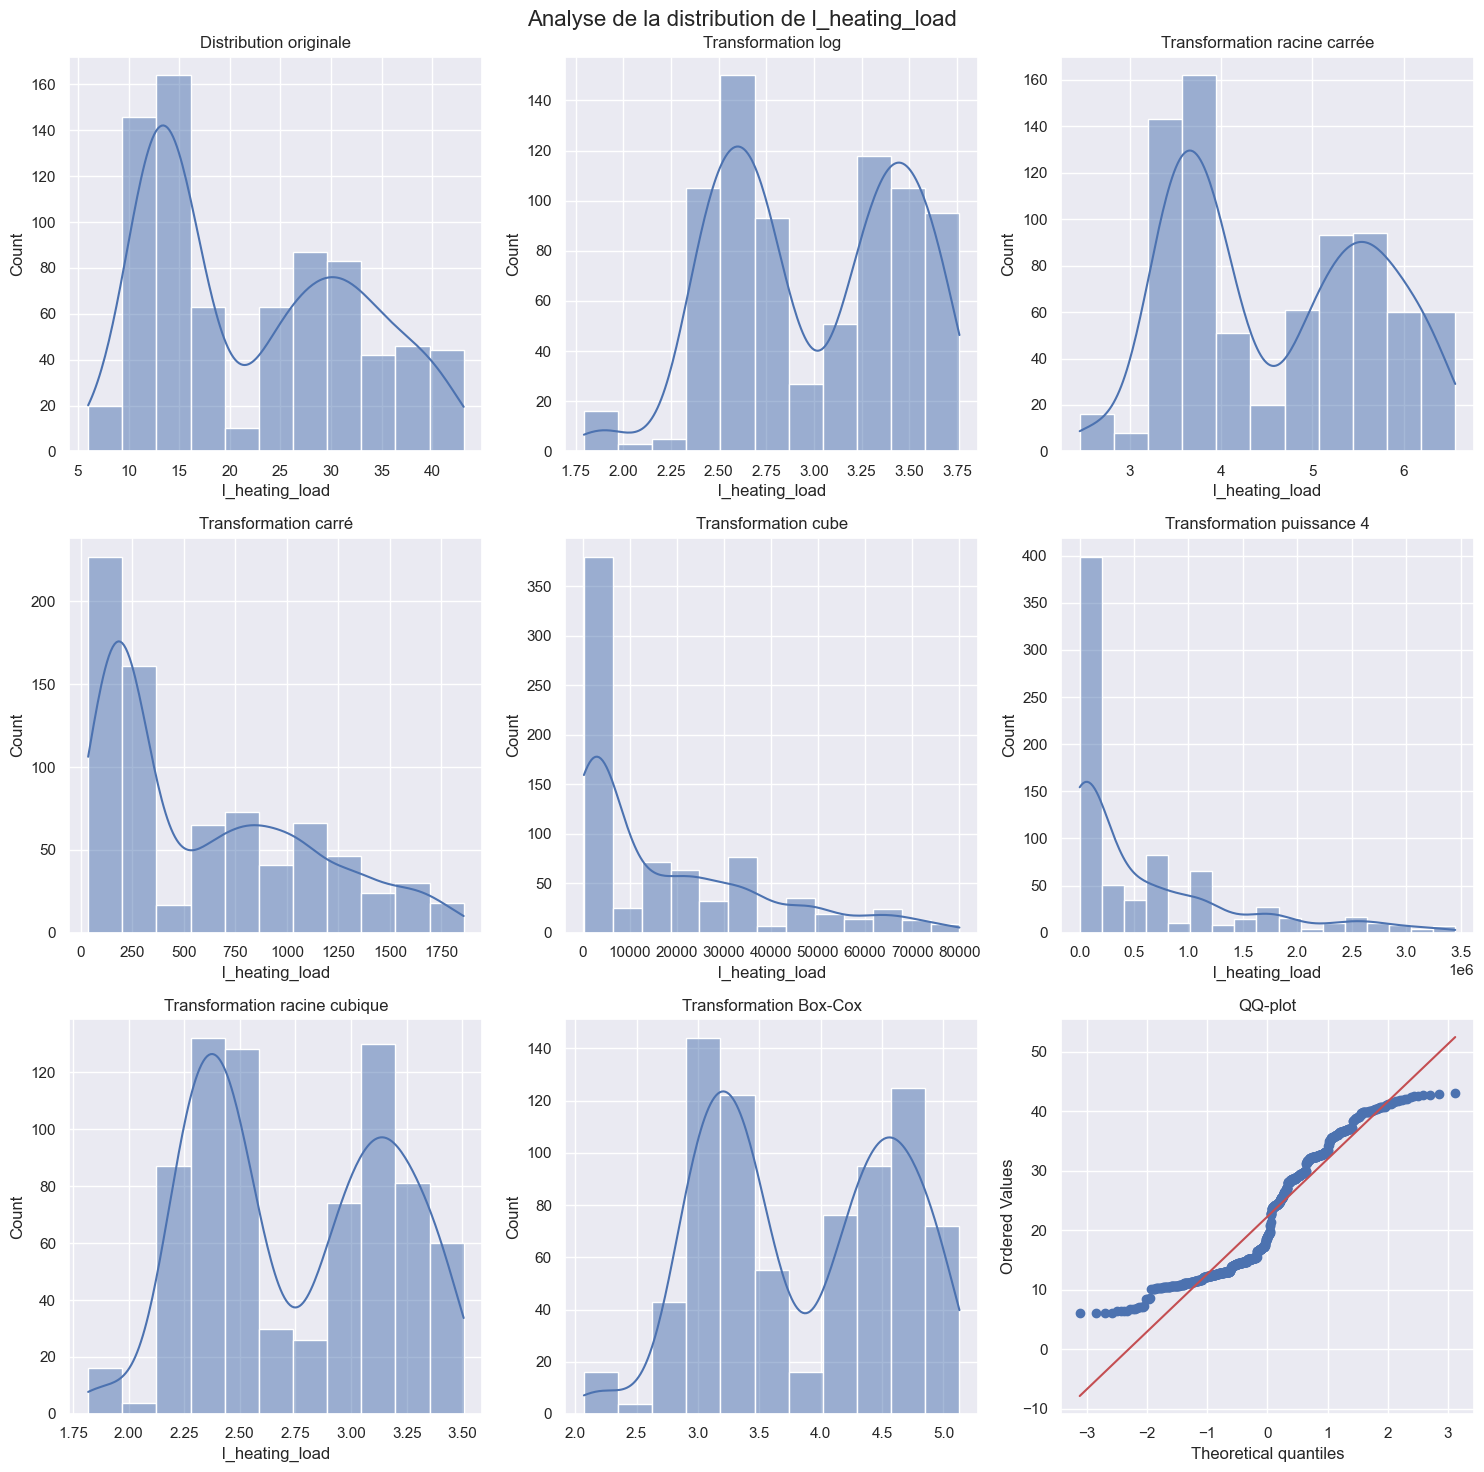


Analyse de la distribution de l_cooling_load
Analyse de la distribution de l_cooling_load
------------------------------------------------------------
Statistiques descriptives :
Moyenne: 24.59
Médiane: 22.08
Écart-type: 9.51
Skewness: 0.40
Kurtosis: -1.15
Statistiques après transformation log :
Skewness: 0.06
Kurtosis: -1.46
Statistiques après transformation racine carrée :
Skewness: 0.22
Kurtosis: -1.36
Statistiques après transformation carré :
Skewness: 0.81
Kurtosis: -0.27
Statistiques après transformation cube :
Skewness: 1.31
Kurtosis: 1.38
Statistiques après transformation puissance 4 :
Skewness: 1.88
Kurtosis: 3.97
Statistiques après transformation racine cubique :
Skewness: 0.16
Kurtosis: -1.41
Statistiques après transformation Box-Cox :
Skewness: 0.02
Kurtosis: -1.46


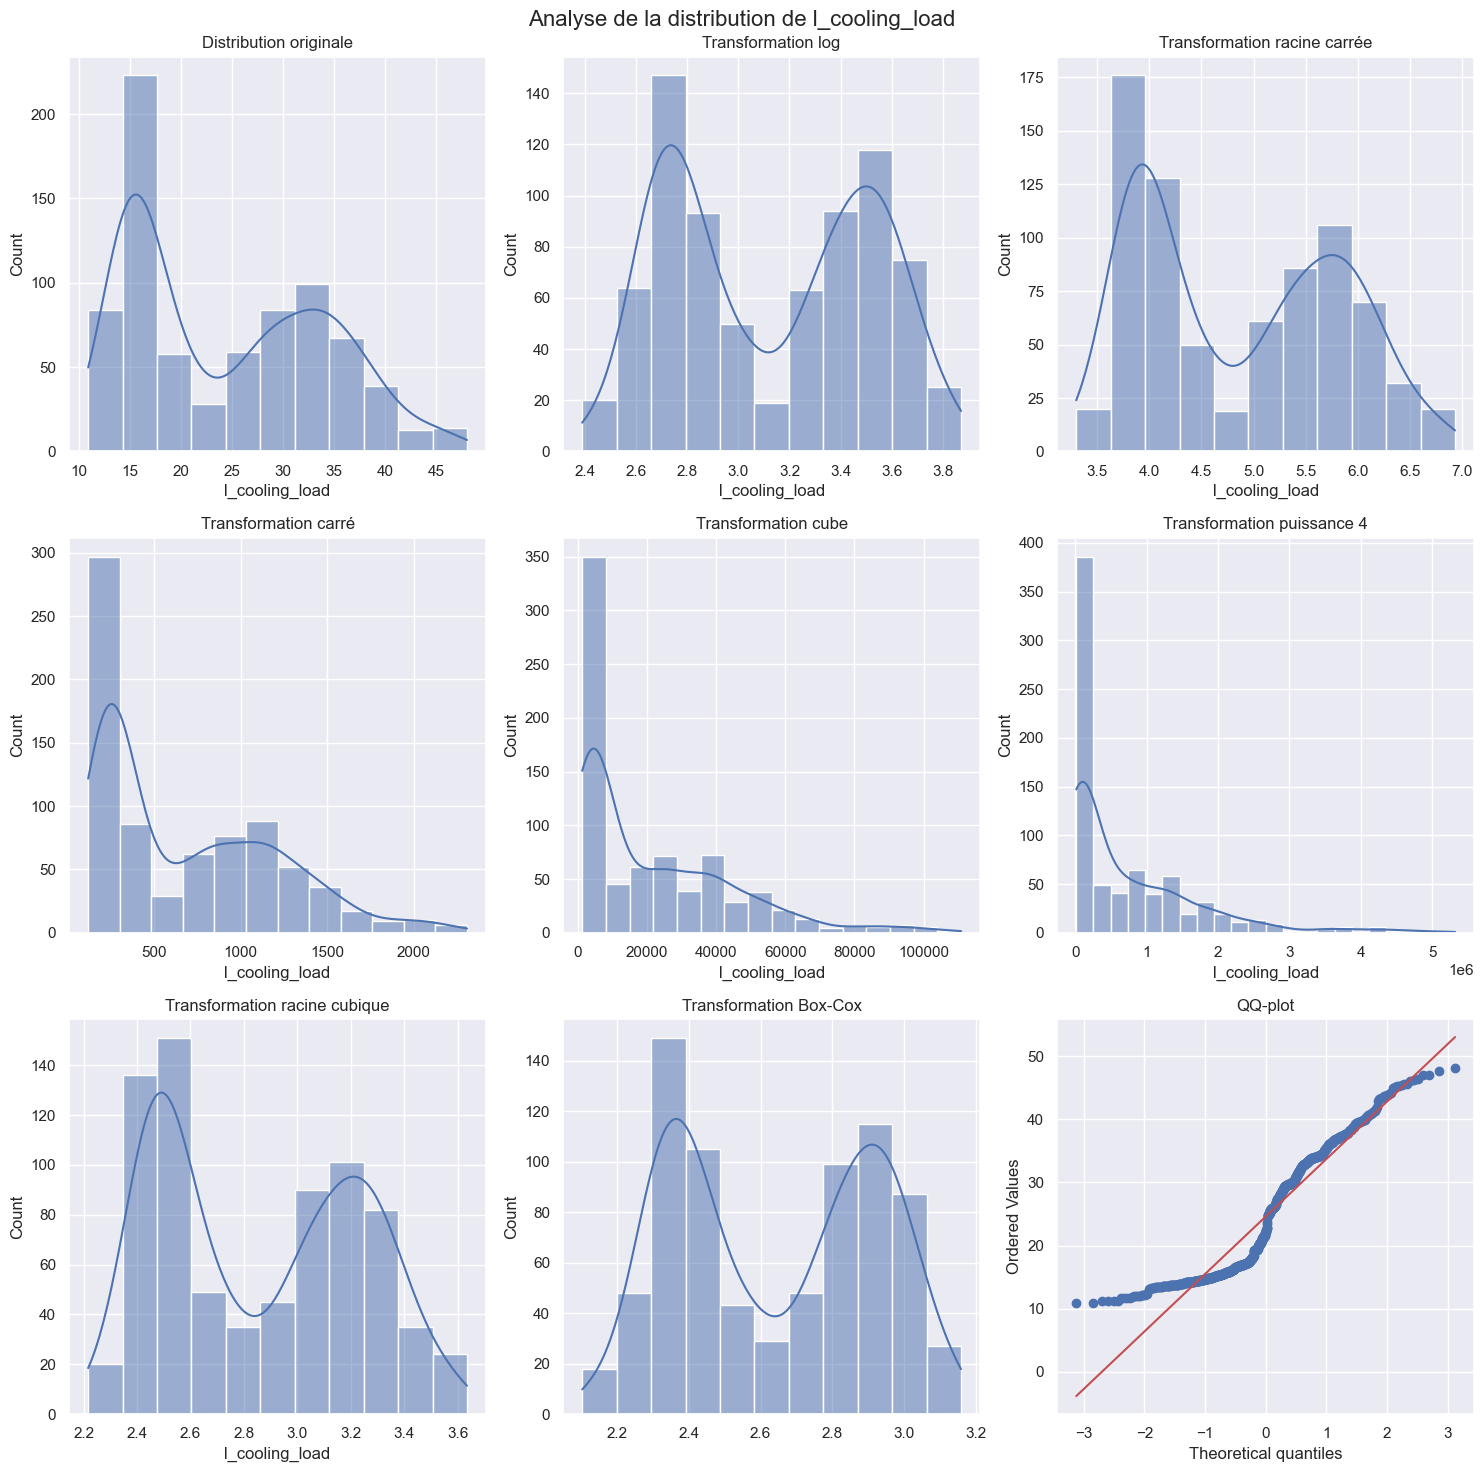

In [9]:
# Analyse des distributions pour chaque label
for file_name, df in normalized_data_converted.items():
    print(f"\nAnalyse des distributions pour le fichier : {file_name}")
    labels = [col for col in df.columns if col.startswith('l_')]

    for label in labels:
        print(f"\nAnalyse de la distribution de {label}")
        analyze_distribution(df, label)


## 12. Analyse GPT des distributions

### Objectif
Utiliser un modèle GPT pour analyser les résultats des transformations et recommander la transformation la plus appropriée pour chaque label dans le cadre d'un modèle linéaire.


In [10]:
def analyze_distributions_with_gpt(file_name, label_stats):
    """
    Analyse les distributions des labels avec GPT et recommande des transformations.
    
    Args:
        file_name (str): Nom du fichier analysé
        label_stats (dict): Dictionnaire contenant les statistiques des labels et leurs transformations
        
    Returns:
        list: Liste de dictionnaires contenant les recommandations pour chaque label
    """
    import openai
    from dotenv import load_dotenv
    import os
    import json
    
    # Charger les variables d'environnement
    load_dotenv()
    
    # Vérifier la présence de la clé API
    if not os.getenv('OPENAI_API_KEY'):
        print("Erreur: La clé API OpenAI n'est pas définie dans le fichier .env")
        return []
    
    # Configurer la clé API
    openai.api_key = os.getenv('OPENAI_API_KEY')
    
    recommendations = []
    
    for label, stats in label_stats.items():
        # Préparer le prompt pour GPT
        prompt = f"""Analyse la distribution de la variable {label} du fichier {file_name} et recommande la meilleure transformation pour un modèle linéaire.

Statistiques originales:
- Skewness: {stats['original']['skewness']:.2f}
- Kurtosis: {stats['original']['kurtosis']:.2f}

Statistiques après transformations:
"""
        
        # Ajouter les statistiques des transformations
        for trans_name, trans_stats in stats['transformations'].items():
            prompt += f"- {trans_name}:\n"
            prompt += f"  - Skewness: {trans_stats['skewness']:.2f}\n"
            prompt += f"  - Kurtosis: {trans_stats['kurtosis']:.2f}\n"
        
        prompt += """
Recommandation:
1. Analyse la distribution originale et les transformations
2. Identifie la transformation qui donne la distribution la plus proche d'une distribution normale
3. Justifie ton choix en te basant sur la skewness et la kurtosis
4. Retourne ta réponse au format JSON suivant:
{
    "label": "nom_du_label",
    "transformation": "nom_de_la_transformation_recommandée",
    "justification": "explication détaillée du choix"
}
"""
        
        try:
            # Appel à l'API OpenAI
            response = openai.chat.completions.create(
                model="gpt-3.5-turbo",
                messages=[
                    {"role": "system", "content": "Tu es un expert en analyse de données et en statistiques."},
                    {"role": "user", "content": prompt}
                ],
                temperature=0.7
            )
            
            # Extraire la réponse JSON
            response_text = response.choices[0].message.content
            try:
                # Essayer d'extraire le JSON de la réponse
                start_idx = response_text.find('{')
                end_idx = response_text.rfind('}') + 1
                json_str = response_text[start_idx:end_idx]
                recommendation = json.loads(json_str)
                recommendations.append(recommendation)
            except (json.JSONDecodeError, ValueError) as e:
                print(f"Erreur lors de l'analyse de la réponse pour {label}: {str(e)}")
                print(f"Réponse reçue: {response_text}")
                recommendations.append({
                    "label": label,
                    "transformation": "none",
                    "justification": "Erreur lors de l'analyse de la réponse"
                })
                
        except Exception as e:
            print(f"Erreur lors de l'appel à l'API OpenAI pour {label}: {str(e)}")
            recommendations.append({
                "label": label,
                "transformation": "none",
                "justification": "Erreur lors de l'appel à l'API"
            })
    
    return recommendations


In [11]:
# Stocker les résultats de l'analyse GPT et les features à éliminer
gpt_results = {}
features_to_eliminate = set()

# Collecter les statistiques pour chaque label
for file_name, df in normalized_data_converted.items():
    print(f"{'='*80}")
    print(f"Analyse GPT des distributions pour {file_name}")
    print(f"{'='*80}")
    
    # Identifier les labels (préfixe 'l_')
    labels = [col for col in df.columns if col.startswith('l_')]
    
    # Collecter les statistiques pour chaque label
    label_stats = {}
    for label in labels:
        # Distribution originale
        original_stats = {
            'skewness': df[label].skew(),
            'kurtosis': df[label].kurtosis()
        }
        
        # Transformations
        transformations = {}
        
        # Box-Cox
        if (df[label] > 0).all():
           boxcox_col, _ = stats.boxcox(df[label])
           transformations['boxcox'] = {
               'skewness': pd.Series(boxcox_col).skew(),
               'kurtosis': pd.Series(boxcox_col).kurtosis()
        }
    
        # Log
        if (df[label] > 0).all():
            log_col = np.log(df[label])
            transformations['log'] = {
                'skewness': log_col.skew(),
                'kurtosis': log_col.kurtosis()
            }
        
        # Racine carrée
        if (df[label] >= 0).all():
            sqrt_col = np.sqrt(df[label])
            transformations['sqrt'] = {
                'skewness': sqrt_col.skew(),
                'kurtosis': sqrt_col.kurtosis()
            }
        
        # Carré
        square_col = df[label] ** 2
        transformations['square'] = {
            'skewness': square_col.skew(),
            'kurtosis': square_col.kurtosis()
        }
        
        # Cube
        cube_col = df[label] ** 3
        transformations['cube'] = {
            'skewness': cube_col.skew(),
            'kurtosis': cube_col.kurtosis()
        }
        
        # Puissance 4
        power4_col = df[label] ** 4
        transformations['power4'] = {
            'skewness': power4_col.skew(),
            'kurtosis': power4_col.kurtosis()
        }
        
        # Racine cubique
        if (df[label] >= 0).all():
            cbrt_col = np.cbrt(df[label])
            transformations['cbrt'] = {
                'skewness': cbrt_col.skew(),
                'kurtosis': cbrt_col.kurtosis()
            }
        

        
        label_stats[label] = {
            'original': original_stats,
            'transformations': transformations
        }
    
    # Analyser avec GPT et stocker les résultats
    gpt_results[file_name] = analyze_distributions_with_gpt(file_name, label_stats)
    
    # Afficher les résultats de l'analyse GPT
    print("\nRésultats de l'analyse GPT :")
    for result in gpt_results[file_name]:
        print(f"\nAnalyse pour {result['label']} :")
        print(f"Transformation recommandée : {result['transformation']}")
        print(f"Justification : {result['justification']}")
        print("-" * 40)

Analyse GPT des distributions pour normalized_ENB2012_data.csv

Résultats de l'analyse GPT :

Analyse pour l_heating_load :
Transformation recommandée : boxcox
Justification : La transformation Box-Cox semble être la plus adéquate pour la variable l_heating_load. En comparant les statistiques de skewness et de kurtosis après transformation, on remarque que la Skewness est très proche de zéro (-0.03) et que la Kurtosis (-1.24) reste relativement proche de la distribution normale. Une distribution proche de la normale est favorable pour les modèles linéaires car cela facilite l'interprétation des coefficients et des intervalles de confiance. De plus, la transformation Box-Cox est flexible et peut s'adapter à différentes distributions, ce qui en fait un bon choix pour cette variable.
----------------------------------------

Analyse pour l_cooling_load :
Transformation recommandée : boxcox
Justification : La transformation Box-Cox est recommandée car elle permet de réduire la skewness et 

## 13. Transformation des labels et visualisation

### Objectif
Transformer les labels selon les recommandations de GPT et visualiser l'impact des transformations sur les relations avec les features conservées uniquement.


Transformation des labels pour normalized_ENB2012_data.csv
Transformation de l_heating_load avec boxcox:
Avant transformation - Skewness: 0.36, Kurtosis: -1.25
Après transformation - Skewness: -0.03, Kurtosis: -1.24
Transformation de l_cooling_load avec boxcox:
Avant transformation - Skewness: 0.40, Kurtosis: -1.15
Après transformation - Skewness: 0.02, Kurtosis: -1.46
Graphiques pour l_heating_load:


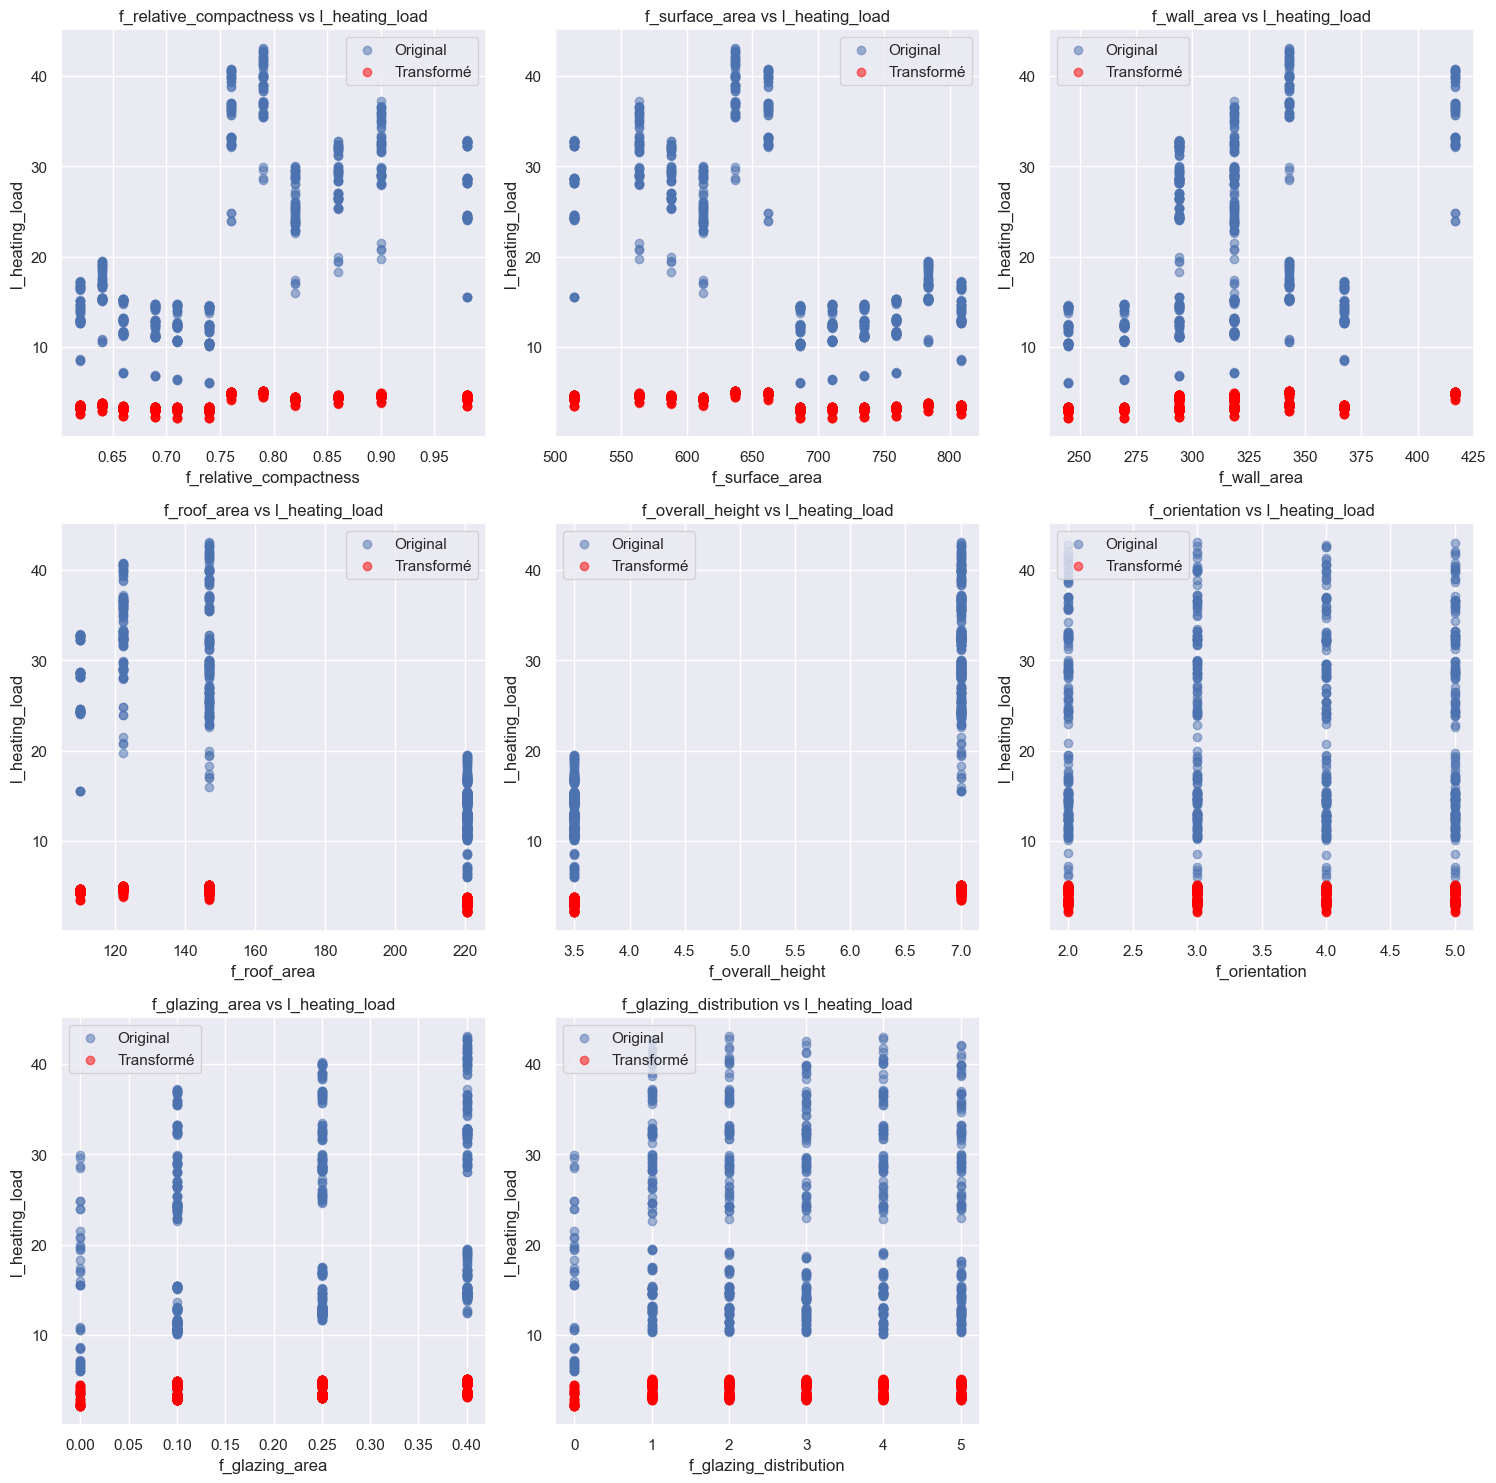

Matrices de corrélation:


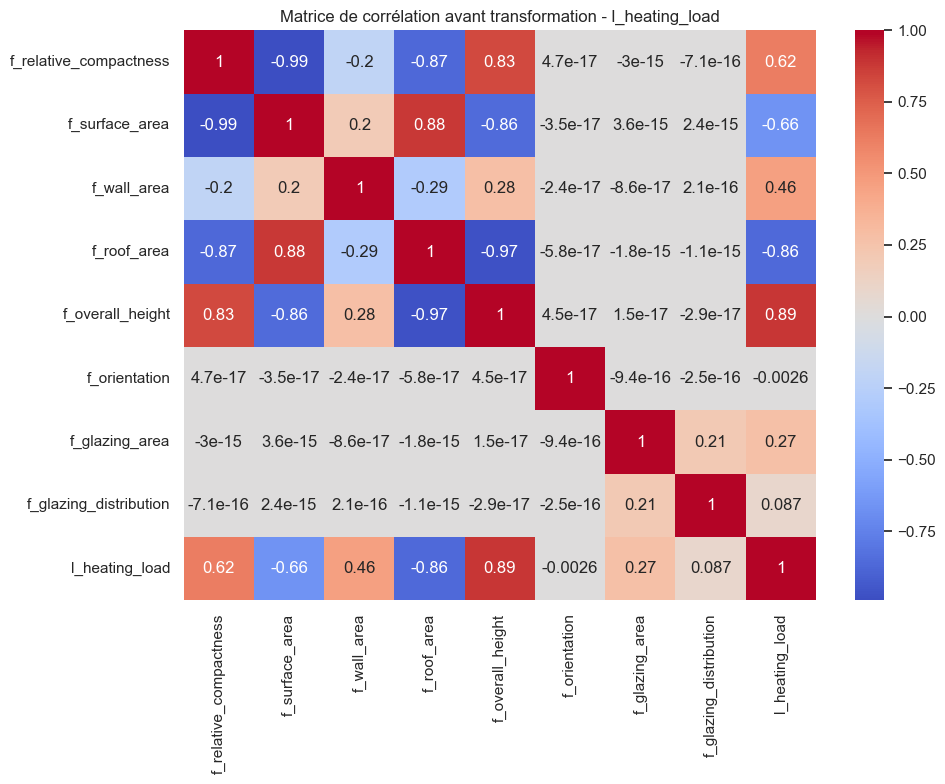

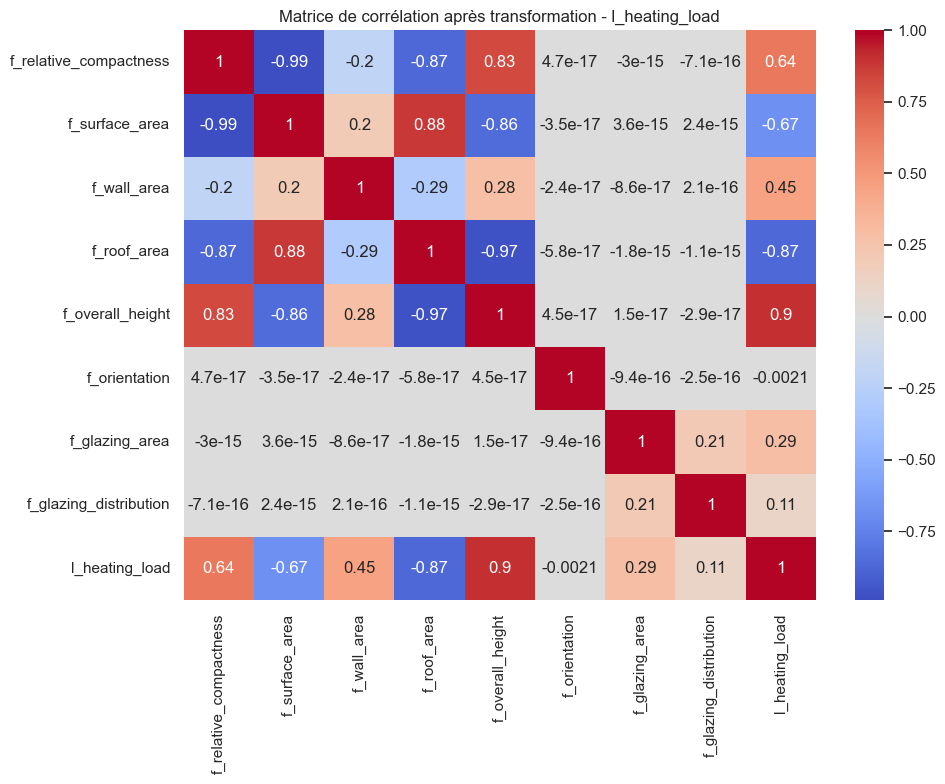

Graphiques pour l_cooling_load:


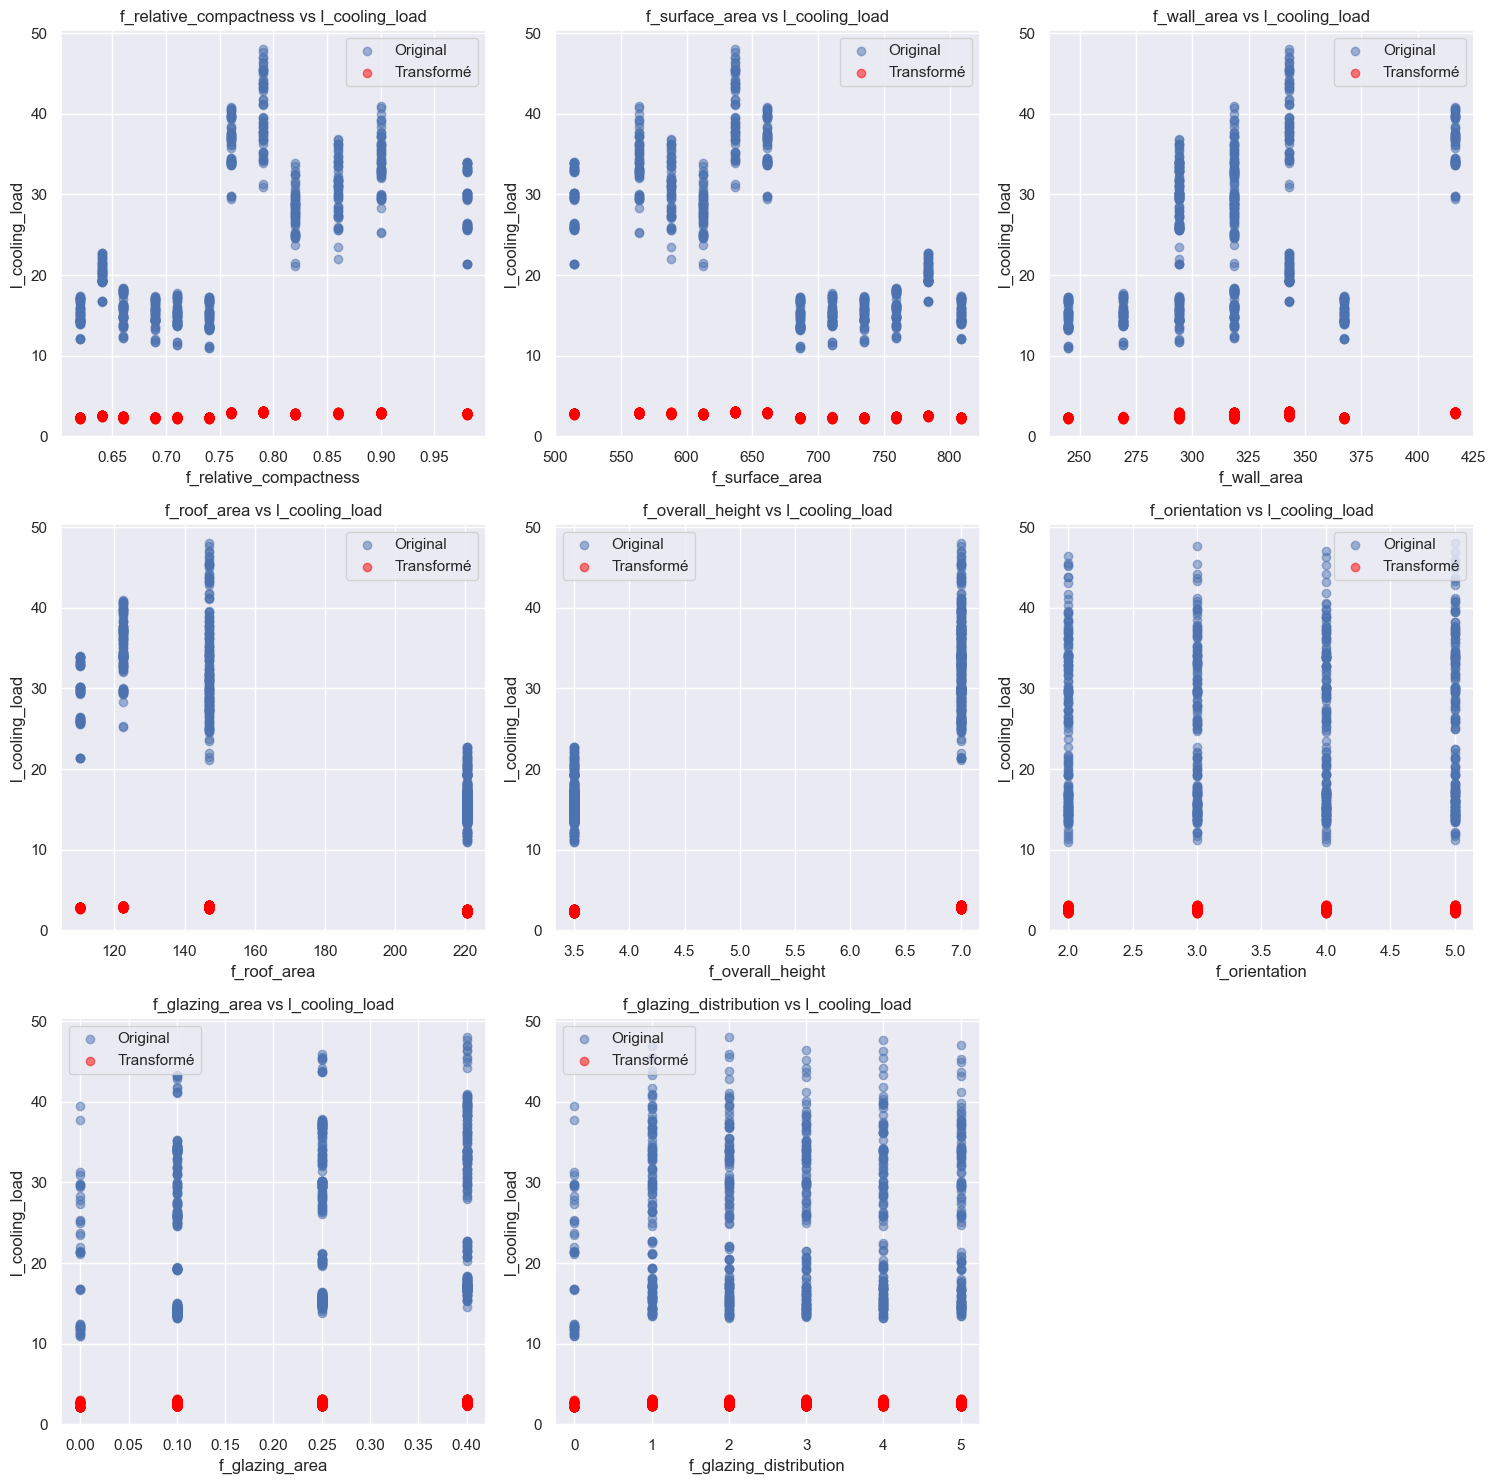

Matrices de corrélation:


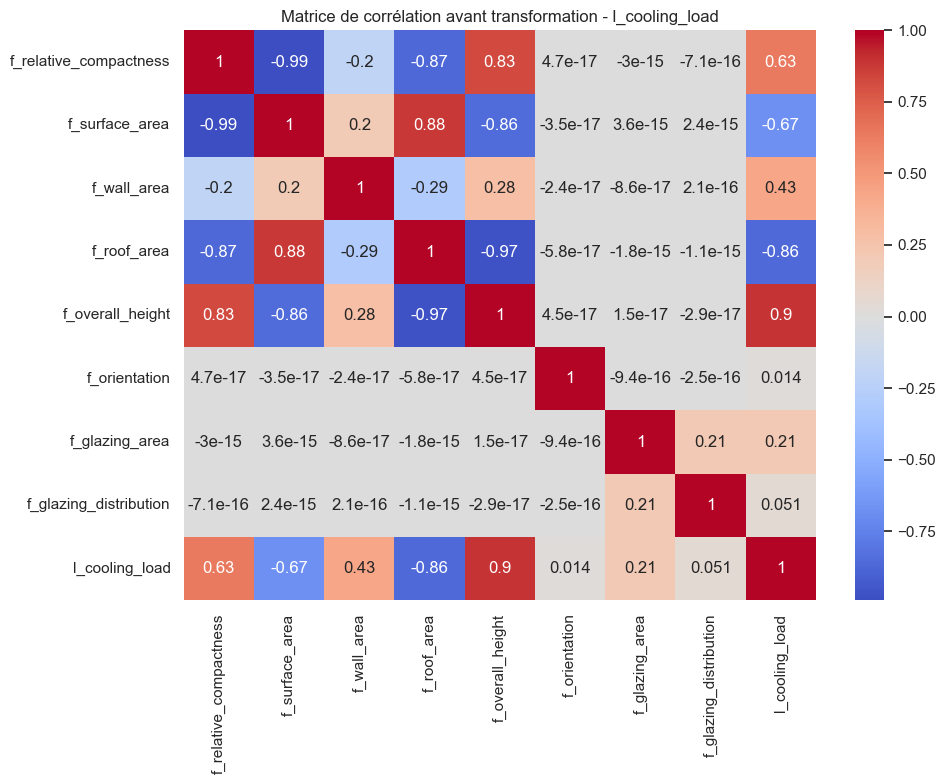

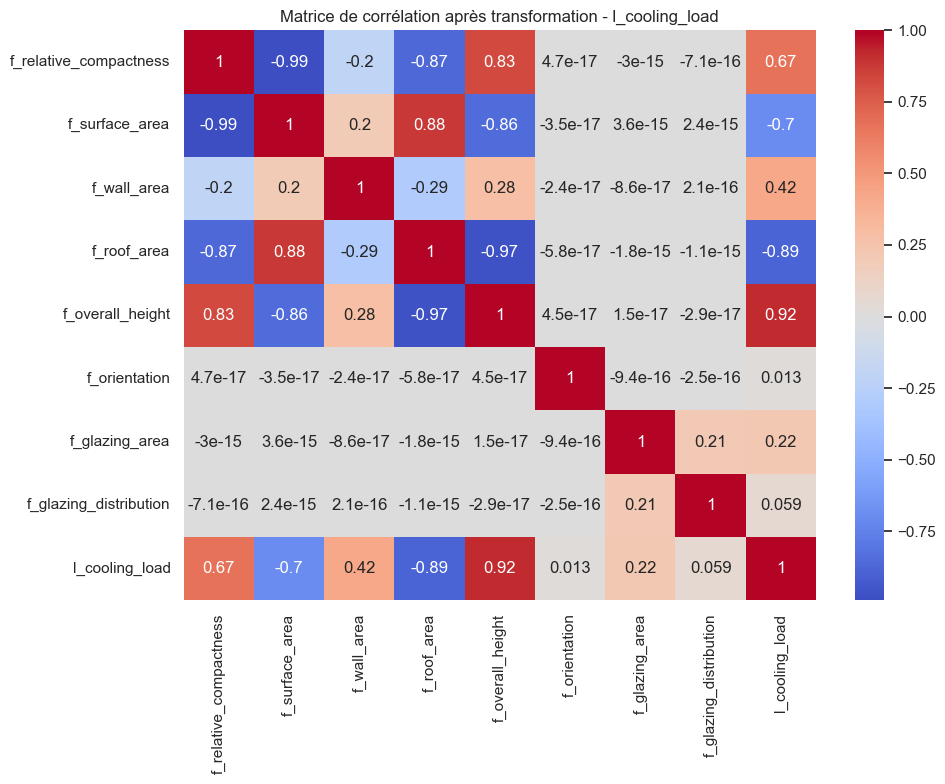

In [12]:
# Transformer les labels selon les recommandations de GPT
for file_name, df in normalized_data_converted.items():
    print(f"{'='*80}")
    print(f"Transformation des labels pour {file_name}")
    print(f"{'='*80}")
    
    # Récupérer les transformations recommandées depuis les résultats stockés
    transformations = gpt_results[file_name]
    
    if transformations:
        # Créer une copie du DataFrame pour les transformations
        df_transformed = df.copy()
        
        # Appliquer les transformations
        for item in transformations:
            label = item['label']
            transformation = item['transformation']
            
            if transformation and transformation.lower() != 'none':
                print(f"Transformation de {label} avec {transformation}:")
                
                # Appliquer la transformation appropriée
                if transformation.lower() == 'log':
                    df_transformed[label] = np.log(df[label])
                elif transformation.lower() == 'sqrt':
                    df_transformed[label] = np.sqrt(df[label])
                elif transformation.lower() == 'square':
                    df_transformed[label] = df[label] ** 2
                elif transformation.lower() == 'cube':
                    df_transformed[label] = df[label] ** 3
                elif transformation.lower() == 'power4':
                    df_transformed[label] = df[label] ** 4
                elif transformation.lower() == 'cbrt':
                    df_transformed[label] = np.cbrt(df[label])
                elif transformation.lower() == 'boxcox':
                    df_transformed[label], _ = stats.boxcox(df[label])
                
                # Afficher les statistiques avant/après
                print(f"Avant transformation - Skewness: {df[label].skew():.2f}, Kurtosis: {df[label].kurtosis():.2f}")
                print(f"Après transformation - Skewness: {df_transformed[label].skew():.2f}, Kurtosis: {df_transformed[label].kurtosis():.2f}")
        
       
        features = [col for col in df.columns if col.startswith('f_')]
        labels = [col for col in df.columns if col.startswith('l_')]
        
        for label in labels:
            print(f"Graphiques pour {label}:")
            n_features = len(features)
            n_cols = 3
            n_rows = (n_features + n_cols - 1) // n_cols
            
            fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
            axes = axes.flatten()
            
            for i, feature in enumerate(features):
                # Graphique avant transformation
                axes[i].scatter(df[feature], df[label], alpha=0.5, label='Original')
                axes[i].set_xlabel(feature)
                axes[i].set_ylabel(label)
                axes[i].set_title(f'{feature} vs {label}')
                axes[i].legend()
                
                # Graphique après transformation
                if label in df_transformed.columns:
                    axes[i].scatter(df[feature], df_transformed[label], alpha=0.5, color='red', label='Transformé')
                    axes[i].legend()
            
            # Cacher les axes inutilisés
            for j in range(i+1, len(axes)):
                axes[j].set_visible(False)
            
            plt.tight_layout()
            plt.show()
            
            # Afficher les matrices de corrélation avant/après
            print("Matrices de corrélation:")
            
            # Avant transformation
            corr_before = df[features + [label]].corr()
            plt.figure(figsize=(10, 8))
            sns.heatmap(corr_before, annot=True, cmap='coolwarm', center=0)
            plt.title(f'Matrice de corrélation avant transformation - {label}')
            plt.tight_layout()
            plt.show()
            
            # Après transformation
            if label in df_transformed.columns:
                corr_after = df_transformed[features + [label]].corr()
                plt.figure(figsize=(10, 8))
                sns.heatmap(corr_after, annot=True, cmap='coolwarm', center=0)
                plt.title(f'Matrice de corrélation après transformation - {label}')
                plt.tight_layout()
                plt.show()

## 7. Analyse des corrélations

Analyse du fichier normalized_ENB2012_data.csv:
  Colonnes numériques trouvées: 8
Matrice de corrélation pour normalized_ENB2012_data.csv:
                        f_relative_compactness  f_surface_area   f_wall_area  \
f_relative_compactness            1.000000e+00   -9.919015e-01 -2.037817e-01   
f_surface_area                   -9.919015e-01    1.000000e+00  1.955016e-01   
f_wall_area                      -2.037817e-01    1.955016e-01  1.000000e+00   
f_roof_area                      -8.688234e-01    8.807195e-01 -2.923165e-01   
f_overall_height                  8.277473e-01   -8.581477e-01  2.809757e-01   
f_glazing_area                   -2.960552e-15    3.636925e-15 -8.567455e-17   
l_heating_load                    6.222719e-01   -6.581199e-01  4.556714e-01   
l_cooling_load                    6.343391e-01   -6.729989e-01  4.271170e-01   

                         f_roof_area  f_overall_height  f_glazing_area  \
f_relative_compactness -8.688234e-01      8.277473e-01   -2.960552

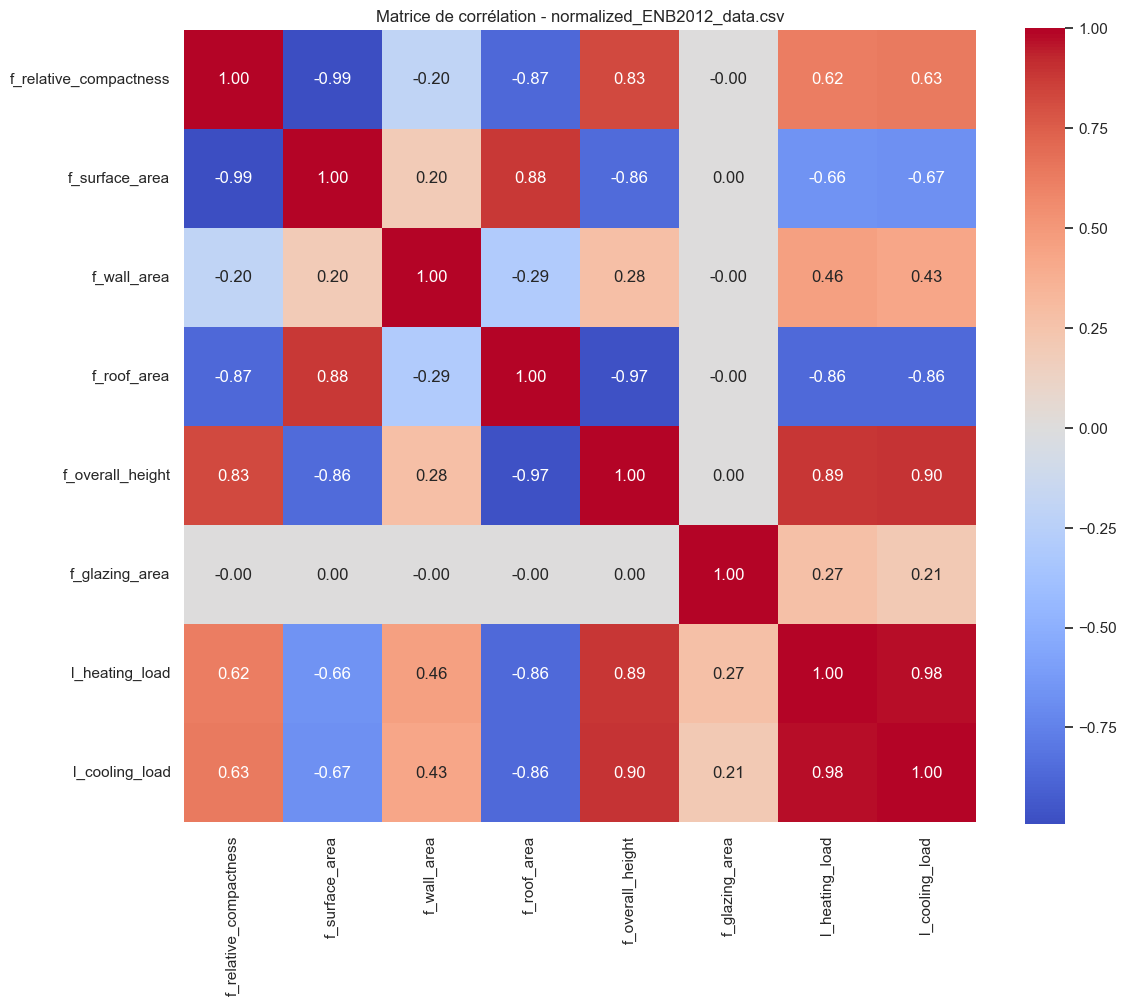

In [13]:
# Fonction pour créer la matrice de corrélation
def create_correlation_matrix(data_dict):
    """
    Crée une matrice de corrélation pour chaque DataFrame dans le dictionnaire.
    
    Args:
        data_dict (dict): Dictionnaire de DataFrames
        
    Returns:
        dict: Dictionnaire contenant les matrices de corrélation
    """
    correlation_matrices = {}
    
    for file_name, df in data_dict.items():
        print(f"Analyse du fichier {file_name}:")
        
        # Vérifier si le DataFrame est vide
        if df.empty:
            print(f"  Attention: Le DataFrame {file_name} est vide!")
            continue
            
        # Sélectionner uniquement les colonnes numériques
        numeric_cols = [col for col in df.columns if df[col].dtype in ['int64', 'float64']]
        
        # Vérifier s'il y a des colonnes numériques
        if len(numeric_cols) == 0:
            print(f"  Attention: Aucune colonne numérique trouvée dans {file_name}!")
            print("  Types de colonnes présents:", df.dtypes.unique())
            continue
            
        print(f"  Colonnes numériques trouvées: {len(numeric_cols)}")
        
        # Créer la matrice de corrélation
        corr_matrix = df[numeric_cols].corr()
        
        correlation_matrices[file_name] = corr_matrix
    
    return correlation_matrices

# Créer les matrices de corrélation pour les données normalisées converties
correlation_matrices = create_correlation_matrix(normalized_data_converted)

# Afficher les matrices de corrélation
for file_name, corr_matrix in correlation_matrices.items():
    print(f"Matrice de corrélation pour {file_name}:")
    print(corr_matrix)
    
    # Créer un heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, 
                annot=True, 
                cmap='coolwarm', 
                center=0,
                fmt='.2f',
                square=True)
    plt.title(f'Matrice de corrélation - {file_name}')
    plt.tight_layout()
    plt.show()

## 8. Test d'indépendance des variables catégorielles

### Démarche d'analyse

Pour tester l'indépendance entre les features catégorielles (f_orientation et f_glazing_distribution), nous utilisons :

- **Test exact de Fisher** :
  * H0 : Les variables sont indépendantes
  * H1 : Il existe une dépendance entre les variables
  * Interprétation : Si p-value < 0.05, on rejette H0 et on conclut à une dépendance entre les variables


In [14]:
# Test d'indépendance entre variables catégorielles
from scipy.stats import fisher_exact
import pandas as pd

def test_categorical_independence(df, var1, var2):
    """
    Teste l'indépendance entre deux variables catégorielles avec le test exact de Fisher.
    
    Args:
        df (pd.DataFrame): DataFrame contenant les données
        var1 (str): Nom de la première variable catégorielle
        var2 (str): Nom de la deuxième variable catégorielle
    """
    print(f"Test d'indépendance entre {var1} et {var2}")
    print("-" * 60)
    
    # Créer la table de contingence
    contingency = pd.crosstab(df[var1], df[var2])
    print("Table de contingence :")
    display(contingency)
    
    # Test de Fisher
    odds_ratio, p_value = fisher_exact(contingency)
    
    # Affichage des résultats
    print(f"Test exact de Fisher :")
    print(f"p-value: {p_value:.4f}")
    
    # Interprétation
    print("Interprétation:")
    if p_value < 0.05:
        print("→ p-value < 0.05 : On rejette l'hypothèse d'indépendance")
        print("→ Les variables ne sont pas indépendantes (elles sont liées)")
    else:
        print("→ p-value ≥ 0.05 : On ne peut pas rejeter l'hypothèse d'indépendance")
        print("→ Pas de preuve statistique d'une dépendance entre les variables")

# Analyser l'indépendance des variables catégorielles
for file_name, df in normalized_data_converted.items():
    print(f"{'='*80}")
    print(f"Analyse d'indépendance des variables catégorielles pour {file_name}")
    print(f"{'='*80}")
    
    # Identifier les features catégorielles (préfixe 'f_')
    categorical_features = [col for col in df.columns if df[col].dtype.name == 'category' and col.startswith('f_')]
    
    # Tester l'indépendance entre chaque paire de features catégorielles
    for i in range(len(categorical_features)):
        for j in range(i+1, len(categorical_features)):
            test_categorical_independence(df, categorical_features[i], categorical_features[j])


Analyse d'indépendance des variables catégorielles pour normalized_ENB2012_data.csv
Test d'indépendance entre f_orientation et f_glazing_distribution
------------------------------------------------------------
Table de contingence :


f_glazing_distribution,0,1,2,3,4,5
f_orientation,,,,,,
2,12,36,36,36,36,36
3,12,36,36,36,36,36
4,12,36,36,36,36,36
5,12,36,36,36,36,36


Test exact de Fisher :
p-value: 1.0000
Interprétation:
→ p-value ≥ 0.05 : On ne peut pas rejeter l'hypothèse d'indépendance
→ Pas de preuve statistique d'une dépendance entre les variables


## 10. Sélection des features

### Démarche d'analyse
Nous allons appliquer l'algorithme de sélection des features en trois étapes :

1. **Sélection initiale des features numériques** :
   - Calcul de la somme des corrélations absolues avec tous les labels pour chaque feature
   - Tri des features par ordre décroissant de cette somme (les plus corrélées d'abord)
   - Sélection itérative en évitant la multicolinéarité :
     * On prend la première feature (la plus corrélée avec les labels)
     * Pour chaque feature restante, on la garde uniquement si sa corrélation avec toutes les features déjà sélectionnées est ≤ 0.85
     * Cela permet d'éviter la redondance d'information tout en gardant les features les plus pertinentes

2. **Sélection des features catégorielles** :
   - Calcul d'un score de "corrélation" pour chaque feature catégorielle :
     * Pour chaque label, on effectue un test statistique (Wilcoxon ou Kruskal-Wallis selon le nombre de classes)
     * Le score est la somme des -log(p-value) pour tous les labels
     * Plus le score est élevé, plus la feature est liée aux labels
   - Tri des features par score décroissant
   - Élimination des redondances :
     * Test de Fisher entre chaque paire de features catégorielles
     * Si dépendance détectée (p-value < 0.05), on garde celle avec le meilleur score

3. **Validation finale** :
   - Pour chaque paire (feature numérique, feature catégorielle) :
     * Test statistique pour vérifier leur indépendance
     * Si dépendance détectée (p-value < 0.05), on élimine la feature catégorielle
     * Cela permet d'éviter la redondance entre types de features différents


In [15]:
# Initialiser les ensembles pour stocker les features
features_to_keep = set()
features_to_eliminate = set()

for file_name, df in normalized_data_converted.items():
    print(f"{'='*80}")
    print(f"Sélection des features pour {file_name}")
    print(f"{'='*80}")
    
    # Identifier les features numériques et catégorielles
    numeric_features = [col for col in df.columns if col.startswith('f_') and df[col].dtype in ['int64', 'float64']]
    categorical_features = [col for col in df.columns if col.startswith('f_') and df[col].dtype.name == 'category']
    labels = [col for col in df.columns if col.startswith('l_')]
    
    print("Features numériques initiales:", numeric_features)
    print("Features catégorielles initiales:", categorical_features)
    print("Labels:", labels)
    
    # 1. Sélection initiale des features numériques
    print("1. Sélection des features numériques")
    print("-" * 40)
    
    # Calculer la somme des corrélations absolues avec les labels
    corr_sums = {}
    for feature in numeric_features:
        corr_sum = sum(abs(df[feature].corr(df[label])) for label in labels)
        corr_sums[feature] = corr_sum
    
    # Trier les features par corrélation décroissante
    sorted_features = sorted(corr_sums.items(), key=lambda x: x[1], reverse=True)
    
    # Sélectionner les features en évitant les corrélations élevées
    selected_numeric = []
    for feature, _ in sorted_features:
        if not selected_numeric:
            selected_numeric.append(feature)
        else:
            # Vérifier les corrélations avec les features déjà sélectionnées
            correlations = [abs(df[feature].corr(df[f])) for f in selected_numeric]
            if all(corr <= 0.85 for corr in correlations):
                selected_numeric.append(feature)
    
    print("Features numériques sélectionnées:", selected_numeric)
    
    # 2. Sélection des features catégorielles
    print("2. Sélection des features catégorielles")
    print("-" * 40)
    
    # Calculer les scores pour chaque feature catégorielle
    categorical_scores = {}
    for feature in categorical_features:
        total_score = 0
        for label in labels:
            groups = [group[label].values for name, group in df.groupby(feature, observed=False)]
            if len(groups) == 2:
                # Test de Wilcoxon
                _, p_value = stats.mannwhitneyu(groups[0], groups[1], alternative='two-sided')
            else:
                # Test de Kruskal-Wallis
                _, p_value = stats.kruskal(*groups)
            total_score += -np.log(p_value) if p_value > 0 else 1000
        categorical_scores[feature] = total_score
    
    # Trier les features catégorielles par score
    sorted_categorical = sorted(categorical_scores.items(), key=lambda x: x[1], reverse=True)
    selected_categorical = [f[0] for f in sorted_categorical]
    
    # Tester l'indépendance entre paires de features catégorielles
    to_eliminate = set()
    for i in range(len(selected_categorical)):
        if selected_categorical[i] in to_eliminate:
            continue
        for j in range(i + 1, len(selected_categorical)):
            if selected_categorical[j] in to_eliminate:
                continue
            
            # Test de Fisher
            contingency = pd.crosstab(df[selected_categorical[i]], df[selected_categorical[j]])
            _, p_value = stats.fisher_exact(contingency)
            
            if p_value < 0.05:  # Dépendance détectée
                # Garder celle avec le score le plus élevé
                if categorical_scores[selected_categorical[i]] >= categorical_scores[selected_categorical[j]]:
                    to_eliminate.add(selected_categorical[j])
                else:
                    to_eliminate.add(selected_categorical[i])
                    break
    
    selected_categorical = [f for f in selected_categorical if f not in to_eliminate]
    print("Features catégorielles sélectionnées:", selected_categorical)
    
    # 3. Dernière passe avec tests statistiques
    print("3. Dernière passe avec tests statistiques")
    print("-" * 40)
    
    categorical_to_eliminate = set()
    for cat_feature in selected_categorical:
        for num_feature in selected_numeric:
            groups = [group[num_feature].values for name, group in df.groupby(cat_feature, observed=False)]
            
            if len(groups) == 2:
                # Test de Wilcoxon
                _, p_value = stats.mannwhitneyu(groups[0], groups[1], alternative='two-sided')
            else:
                # Test de Kruskal-Wallis
                _, p_value = stats.kruskal(*groups)
            
            if p_value < 0.05:
                categorical_to_eliminate.add(cat_feature)
                break
    
    final_categorical = [f for f in selected_categorical if f not in categorical_to_eliminate]
    
    # Mettre à jour les ensembles de features
    features_to_keep.update(selected_numeric + final_categorical)
    features_to_eliminate.update(
        [f for f in numeric_features if f not in selected_numeric] +
        [f for f in categorical_features if f not in final_categorical]
    )
    
    print("Résultats finaux:")
    print("Features conservées:", sorted(features_to_keep))
    print("Features éliminées:", sorted(features_to_eliminate))
    
    # Créer un tableau récapitulatif
    print("Tableau récapitulatif des features :")
    summary_data = []
    
    # Features numériques
    for feature in numeric_features:
        status = "Conservée" if feature in features_to_keep else "Éliminée"
        reason = "Corrélation suffisante avec les labels" if feature in features_to_keep else "Corrélation trop faible ou redondante"
        summary_data.append({
            'Feature': feature,
            'Type': 'Numérique',
            'Status': status,
            'Raison': reason
        })
    
    # Features catégorielles
    for feature in categorical_features:
        status = "Conservée" if feature in features_to_keep else "Éliminée"
        if feature in features_to_keep:
            reason = "Score élevé et indépendance validée"
        elif feature in to_eliminate:
            reason = "Dépendance avec une autre feature catégorielle"
        elif feature in categorical_to_eliminate:
            reason = "Dépendance avec une feature numérique"
        else:
            reason = "Score insuffisant"
        summary_data.append({
            'Feature': feature,
            'Type': 'Catégorielle',
            'Status': status,
            'Raison': reason
        })
    
    # Créer et afficher le DataFrame
    summary_df = pd.DataFrame(summary_data)
    display(summary_df.style
        .set_properties(**{'text-align': 'left'})
        .set_table_styles([
            {'selector': 'th', 'props': [('text-align', 'left')]},
            {'selector': 'td', 'props': [('text-align', 'left')]}
        ])
        .hide(axis='index')
    )
# Construire le dictionnaire filtré
normalized_data_converted_selected = {}
for file_name, df in normalized_data_converted.items():
    # ne garder que les colonnes non éliminées
    cols_to_drop = [f for f in df.columns if f in features_to_eliminate]
    normalized_data_converted_selected[file_name] = df.drop(columns=cols_to_drop)
    # Identifier les features numériques et catégorielles
    numeric_features_sel = [col for col in df.columns if col.startswith('f_') and df[col].dtype in ['int64', 'float64']]
    categorical_features_sel = [col for col in df.columns if col.startswith('f_') and df[col].dtype.name == 'category']
    labels = [col for col in df.columns if col.startswith('l_')]




Sélection des features pour normalized_ENB2012_data.csv
Features numériques initiales: ['f_relative_compactness', 'f_surface_area', 'f_wall_area', 'f_roof_area', 'f_overall_height', 'f_glazing_area']
Features catégorielles initiales: ['f_orientation', 'f_glazing_distribution']
Labels: ['l_heating_load', 'l_cooling_load']
1. Sélection des features numériques
----------------------------------------
Features numériques sélectionnées: ['f_overall_height', 'f_relative_compactness', 'f_wall_area', 'f_glazing_area']
2. Sélection des features catégorielles
----------------------------------------
Features catégorielles sélectionnées: ['f_glazing_distribution', 'f_orientation']
3. Dernière passe avec tests statistiques
----------------------------------------
Résultats finaux:
Features conservées: ['f_glazing_area', 'f_orientation', 'f_overall_height', 'f_relative_compactness', 'f_wall_area']
Features éliminées: ['f_glazing_distribution', 'f_roof_area', 'f_surface_area']
Tableau récapitulatif 

Feature,Type,Status,Raison
f_relative_compactness,Numérique,Conservée,Corrélation suffisante avec les labels
f_surface_area,Numérique,Éliminée,Corrélation trop faible ou redondante
f_wall_area,Numérique,Conservée,Corrélation suffisante avec les labels
f_roof_area,Numérique,Éliminée,Corrélation trop faible ou redondante
f_overall_height,Numérique,Conservée,Corrélation suffisante avec les labels
f_glazing_area,Numérique,Conservée,Corrélation suffisante avec les labels
f_orientation,Catégorielle,Conservée,Score élevé et indépendance validée
f_glazing_distribution,Catégorielle,Éliminée,Dépendance avec une feature numérique


## 13.5. Création de features polynomiales pour les relations non-linéaires

### Objectif
Pour chaque feature qui présente une relation non-linéaire avec un des labels, créer des transformations polynomiales :
- log
- racine carrée
- racine cubique
- carré
- cube
- puissance 4

Ces nouvelles features seront utilisées dans la sélection de modèles qui suit.

### Critère de non-linéarité
Une feature est considérée comme ayant une relation non-linéaire potentielle avec le label si sa corrélation est modérée, c'est-à-dire entre 0.33 et 0.66 (en valeur absolue).


In [16]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import FunctionTransformer

def create_polynomial_features(df, features_to_transform):
    """
    Crée des features polynomiales pour les colonnes spécifiées.
    
    Args:
        df (pd.DataFrame): DataFrame contenant les données
        features_to_transform (list): Liste des noms de colonnes à transformer
        
    Returns:
        pd.DataFrame: DataFrame avec les nouvelles features polynomiales
    """
    # Créer une copie du DataFrame pour ne pas modifier l'original
    df_poly = df.copy()
    
    # Définir les transformations
    transformations = {
        'log': lambda x: np.log1p(x),  # log1p pour gérer les valeurs nulles ou négatives
        'sqrt': lambda x: np.sqrt(x),
        'cbrt': lambda x: np.cbrt(x),
        'square': lambda x: np.square(x),
        'cube': lambda x: np.power(x, 3),
        'power4': lambda x: np.power(x, 4)
    }
    
    # Appliquer les transformations pour chaque feature
    for feature in features_to_transform:
        for trans_name, trans_func in transformations.items():
            # Créer le nom de la nouvelle colonne
            new_col_name = f"{feature}_{trans_name}"
            
            # Appliquer la transformation
            df_poly[new_col_name] = trans_func(df[feature])
    
    return df_poly

def get_polynomial_features(df, target_col):
    """
    Identifie les features qui pourraient bénéficier de transformations polynomiales
    en analysant leur relation avec la variable cible.
    
    Args:
        df (pd.DataFrame): DataFrame contenant les données
        target_col (str): Nom de la colonne cible
        
    Returns:
        list: Liste des noms de colonnes à transformer
    """
    # Calculer le coefficient de corrélation pour chaque feature
    correlations = df.corr()[target_col].abs()
    
    # Sélectionner les features avec une corrélation modérée (entre 0.33 et 0.66)
    features_to_transform = correlations[
        (correlations > 0.33) & (correlations < 0.66)
    ].index.tolist()
    
    # Exclure la colonne cible si elle est dans la liste
    if target_col in features_to_transform:
        features_to_transform.remove(target_col)
    
    return features_to_transform

# Dictionnaire pour stocker les résultats de l'analyse
polynomial_analysis_results = {}

# Appliquer les transformations polynomiales pour chaque fichier
for file_name, df in normalized_data_converted_selected.items():
    print(f"{'='*80}")
    print(f"Création des features polynomiales pour {file_name}")
    print(f"{'='*80}")
    
    # Identifier les labels
    labels = [col for col in df.columns if col.startswith('l_')]
    
    # Pour chaque label, identifier les features à transformer
    for label in labels:
        print(f"\nAnalyse pour le label {label}:")
        
        # Identifier les features à transformer
        features_to_transform = get_polynomial_features(df, label)
        
        if features_to_transform:
            print(f"Features sélectionnées pour transformation: {features_to_transform}")
            
            # Créer les features polynomiales
            df_poly = create_polynomial_features(df, features_to_transform)
            
            # Afficher les nouvelles colonnes créées
            new_columns = [col for col in df_poly.columns if col not in df.columns]
            print(f"Nouvelles colonnes créées: {len(new_columns)}")
            print("Exemple de nouvelles colonnes:")
            display(df_poly[new_columns[:5]].head())
            
            # Stocker les résultats de l'analyse
            polynomial_analysis_results[(file_name, label)] = {
                'features': features_to_transform,
                'new_columns': new_columns,
                'correlations': {f: df[f].corr(df[label]) for f in features_to_transform}
            }
            
            # Mettre à jour le DataFrame dans normalized_data_converted_selected
            normalized_data_converted_selected[file_name] = df_poly
        else:
            print("Aucune feature sélectionnée pour transformation.")

# Créer un tableau de synthèse
print("\nTableau de synthèse des features polynomiales créées:")
summary_data = []
for (file_name, label), results in polynomial_analysis_results.items():
    for feature in results['features']:
        correlation = results['correlations'][feature]
        summary_data.append({
            'Fichier': file_name,
            'Label': label,
            'Feature originale': feature,
            'Corrélation originale': f"{correlation:.3f}",
            'Critère de non-linéarité': "Corrélation modérée (0.33 < |r| < 0.66) suggérant une relation non-linéaire potentielle",
            'Transformations appliquées': "log, sqrt, cbrt, square, cube, power4"
        })

summary_df = pd.DataFrame(summary_data)
display(summary_df.style
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'left')]},
        {'selector': 'td', 'props': [('text-align', 'left')]}
    ])
    .hide(axis='index')
)

Création des features polynomiales pour normalized_ENB2012_data.csv

Analyse pour le label l_heating_load:
Features sélectionnées pour transformation: ['f_relative_compactness', 'f_wall_area']
Nouvelles colonnes créées: 12
Exemple de nouvelles colonnes:


,f_relative_compactness_log,f_relative_compactness_sqrt,f_relative_compactness_cbrt,f_relative_compactness_square,f_relative_compactness_cube
0,0.683097,0.989949,0.993288,0.9604,0.941192
1,0.683097,0.989949,0.993288,0.9604,0.941192
2,0.683097,0.989949,0.993288,0.9604,0.941192
3,0.683097,0.989949,0.993288,0.9604,0.941192
4,0.641854,0.948683,0.965489,0.8100,0.729000



Analyse pour le label l_cooling_load:
Features sélectionnées pour transformation: ['f_relative_compactness', 'f_wall_area']
Nouvelles colonnes créées: 12
Exemple de nouvelles colonnes:


,f_relative_compactness_log,f_relative_compactness_sqrt,f_relative_compactness_cbrt,f_relative_compactness_square,f_relative_compactness_cube
0,0.683097,0.989949,0.993288,0.9604,0.941192
1,0.683097,0.989949,0.993288,0.9604,0.941192
2,0.683097,0.989949,0.993288,0.9604,0.941192
3,0.683097,0.989949,0.993288,0.9604,0.941192
4,0.641854,0.948683,0.965489,0.8100,0.729000



Tableau de synthèse des features polynomiales créées:


Fichier,Label,Feature originale,Corrélation originale,Critère de non-linéarité,Transformations appliquées
normalized_ENB2012_data.csv,l_heating_load,f_relative_compactness,0.622,Corrélation modérée (0.33 < |r| < 0.66) suggérant une relation non-linéaire potentielle,"log, sqrt, cbrt, square, cube, power4"
normalized_ENB2012_data.csv,l_heating_load,f_wall_area,0.456,Corrélation modérée (0.33 < |r| < 0.66) suggérant une relation non-linéaire potentielle,"log, sqrt, cbrt, square, cube, power4"
normalized_ENB2012_data.csv,l_cooling_load,f_relative_compactness,0.634,Corrélation modérée (0.33 < |r| < 0.66) suggérant une relation non-linéaire potentielle,"log, sqrt, cbrt, square, cube, power4"
normalized_ENB2012_data.csv,l_cooling_load,f_wall_area,0.427,Corrélation modérée (0.33 < |r| < 0.66) suggérant une relation non-linéaire potentielle,"log, sqrt, cbrt, square, cube, power4"


## 14. Sélection de modèles linéaires optimaux

### Objectif
Pour chaque label (après transformation selon les recommandations de GPT), nous allons déterminer le meilleur modèle linéaire en utilisant trois approches de régression stepwise :

1. **Forward Selection** :
   - Part d'un modèle vide
   - À chaque étape, ajoute la variable qui améliore le plus le modèle
   - S'arrête quand plus aucune variable n'améliore significativement le modèle

2. **Backward Elimination** :
   - Part d'un modèle avec toutes les variables
   - À chaque étape, retire la variable la moins significative
   - S'arrête quand toutes les variables restantes sont significatives

3. **Bidirectional Elimination** (Stepwise) :
   - Combine Forward et Backward
   - À chaque étape, peut soit ajouter soit retirer une variable
   - S'arrête quand plus aucun changement n'améliore le modèle

Pour chaque approche :
- Critère d'entrée : p-value < 0.05
- Critère de sortie : p-value > 0.1
- Métriques d'évaluation : R² ajusté, AIC, BIC
- Validation sur un jeu de test indépendant (30% des données)


In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm
from itertools import combinations
from sklearn.model_selection import train_test_split

def inverse_transform(y, transformation):
    """
    Applique la transformation inverse aux prédictions.
    """
    if not transformation or transformation.lower() == 'none':
        return y
    elif transformation.lower() == 'log':
        return np.exp(y)
    elif transformation.lower() == 'sqrt':
        return np.square(y)
    elif transformation.lower() == 'square':
        return np.sqrt(y)
    elif transformation.lower() == 'cube':
        return np.cbrt(y)
    elif transformation.lower() == 'power4':
        return np.power(y, 1/4)
    elif transformation.lower() == 'cbrt':
        return np.power(y, 3)
    elif transformation.lower() == 'boxcox':
        return y
    return y

def calculate_metrics(X, y, X_test=None, y_test=None, y_orig=None, y_test_orig=None, transformation=None):
    """
    Calcule les métriques pour un modèle (R² ajusté, AIC, BIC, MSE test, RMSE original).
    """
    model = sm.OLS(y, sm.add_constant(X)).fit()
    metrics = {
        'r2_adj': model.rsquared_adj,
        'aic': model.aic,
        'bic': model.bic,
        'model': model
    }
    
    if X_test is not None and y_test is not None:
        X_test_const = sm.add_constant(X_test)
        y_pred = model.predict(X_test_const)
        metrics['test_r2'] = r2_score(y_test, y_pred)
        
        if y_orig is not None and y_test_orig is not None:
            y_pred_orig = inverse_transform(y_pred, transformation)
            metrics['test_mse'] = mean_squared_error(y_test_orig, y_pred_orig)
            metrics['test_rmse'] = np.sqrt(metrics['test_mse'])
    
    return metrics

def forward_selection(X, y, X_test, y_test, p_enter=0.05):
    """
    Implémentation de la sélection forward.
    """
    features = list(X.columns)
    selected = []
    
    while features:
        best_metric = float('-inf')
        best_feature = None
        best_model = None
        
        for feature in features:
            current_features = selected + [feature]
            X_current = X[current_features]
            metrics = calculate_metrics(X_current, y, X_test[current_features], y_test)
            
            if metrics['model'].pvalues.iloc[-1] < p_enter and metrics['test_r2'] > best_metric:
                best_metric = metrics['test_r2']
                best_feature = feature
                best_model = metrics['model']
        
        if best_feature is None:
            break
            
        selected.append(best_feature)
        features.remove(best_feature)
        print(f"Forward - Ajout de {best_feature} - R² test: {best_metric:.4f}")
    
    return selected

def backward_elimination(X, y, X_test, y_test, p_remove=0.1):
    """
    Implémentation de l'élimination backward.
    """
    features = list(X.columns)
    
    while features:
        metrics = calculate_metrics(X[features], y, X_test[features], y_test)
        model = metrics['model']
        p_values = model.pvalues.iloc[1:]
        max_p_value = p_values.max()
        
        if max_p_value > p_remove:
            worst_feature_idx = p_values.idxmax()
            worst_feature = features[features.index(worst_feature_idx)]
            features.remove(worst_feature)
            print(f"Backward - Retrait de {worst_feature} - p-value: {max_p_value:.4f}, R² test: {metrics['test_r2']:.4f}")
        else:
            break
    
    return features

def stepwise_selection(X, y, X_test, y_test, p_enter=0.05, p_remove=0.1):
    """
    Implémentation de la sélection stepwise bidirectionnelle.
    """
    features = []
    available = list(X.columns)
    
    while True:
        changed = False
        
        # Forward step
        best_metric = float('-inf')
        best_feature = None
        
        for feature in available:
            current_features = features + [feature]
            X_current = X[current_features]
            metrics = calculate_metrics(X_current, y, X_test[current_features], y_test)
            
            if metrics['model'].pvalues.iloc[-1] < p_enter and metrics['test_r2'] > best_metric:
                best_metric = metrics['test_r2']
                best_feature = feature
        
        if best_feature is not None:
            features.append(best_feature)
            available.remove(best_feature)
            print(f"Stepwise - Ajout de {best_feature} - R² test: {best_metric:.4f}")
            changed = True
        
        # Backward step
        if features:
            metrics = calculate_metrics(X[features], y, X_test[features], y_test)
            model = metrics['model']
            p_values = model.pvalues.iloc[1:]
            max_p_value = p_values.max()
            
            if max_p_value > p_remove:
                worst_feature_idx = p_values.idxmax()
                worst_feature = features[features.index(worst_feature_idx)]
                features.remove(worst_feature)
                available.append(worst_feature)
                print(f"Stepwise - Retrait de {worst_feature} - p-value: {max_p_value:.4f}, R² test: {metrics['test_r2']:.4f}")
                changed = True
        
        if not changed:
            break
    
    return features

# Appliquer les trois méthodes pour chaque label
for file_name, df in normalized_data_converted_selected.items():
    print(f"{'='*80}")
    print(f"Sélection de modèles pour {file_name}")
    print(f"{'='*80}")
    
    features = [col for col in df.columns if col.startswith('f_') and col in features_to_keep]
    labels = [col for col in df.columns if col.startswith('l_')]
    
    df_transformed = df.copy()
    
    transformations = gpt_results[file_name]
    if transformations:
        for item in transformations:
            label = item['label']
            transformation = item['transformation']
            
            if transformation and transformation.lower() != 'none':
                if transformation.lower() == 'log':
                    df_transformed[label] = np.log(df[label])
                elif transformation.lower() == 'sqrt':
                    df_transformed[label] = np.sqrt(df[label])
                elif transformation.lower() == 'square':
                    df_transformed[label] = df[label] ** 2
                elif transformation.lower() == 'cube':
                    df_transformed[label] = df[label] ** 3
                elif transformation.lower() == 'power4':
                    df_transformed[label] = df[label] ** 4
                elif transformation.lower() == 'cbrt':
                    df_transformed[label] = np.cbrt(df[label])
                elif transformation.lower() == 'boxcox':
                    df_transformed[label], _ = stats.boxcox(df[label])
    
    for label in labels:
        print(f"Modélisation de {label}")
        print("-" * 40)
        
        X = df[features]
        y = df_transformed[label]
        y_orig = df[label]
        
        X_train, X_test, y_train, y_test, y_orig_train, y_orig_test = train_test_split(
            X, y, y_orig, test_size=0.3, random_state=42
        )
        
        transformation = next((item['transformation'] for item in transformations if item['label'] == label), None)
        
        print("1. Forward Selection")
        forward_features = forward_selection(X_train, y_train, X_test, y_test)
        forward_metrics = calculate_metrics(
            X_train[forward_features], y_train,
            X_test[forward_features], y_test,
            y_orig_train, y_orig_test,
            transformation
        )
        
        print("2. Backward Elimination")
        backward_features = backward_elimination(X_train, y_train, X_test, y_test)
        backward_metrics = calculate_metrics(
            X_train[backward_features], y_train,
            X_test[backward_features], y_test,
            y_orig_train, y_orig_test,
            transformation
        )
        
        print("3. Stepwise Selection")
        stepwise_features = stepwise_selection(X_train, y_train, X_test, y_test)
        stepwise_metrics = calculate_metrics(
            X_train[stepwise_features], y_train,
            X_test[stepwise_features], y_test,
            y_orig_train, y_orig_test,
            transformation
        )
        
        results_data = {
            'Méthode': ['Forward', 'Backward', 'Stepwise'],
            'Features': [forward_features, backward_features, stepwise_features],
            'Nombre de features': [len(forward_features), len(backward_features), len(stepwise_features)],
            'R² ajusté (train)': [forward_metrics['r2_adj'], backward_metrics['r2_adj'], stepwise_metrics['r2_adj']],
            'R² (test)': [forward_metrics['test_r2'], backward_metrics['test_r2'], stepwise_metrics['test_r2']],
            'MSE (test)': [forward_metrics['test_mse'], backward_metrics['test_mse'], stepwise_metrics['test_mse']],
            'RMSE (test)': [forward_metrics['test_rmse'], backward_metrics['test_rmse'], stepwise_metrics['test_rmse']],
            'AIC': [forward_metrics['aic'], backward_metrics['aic'], stepwise_metrics['aic']],
            'BIC': [forward_metrics['bic'], backward_metrics['bic'], stepwise_metrics['bic']]
        }
        
        results_df = pd.DataFrame(results_data)
        print(f"Comparaison des modèles pour {label} (après transformation):")
        display(results_df.style
            .format({
                'R² ajusté (train)': '{:.4f}',
                'R² (test)': '{:.4f}',
                'MSE (test)': '{:.4f}',
                'RMSE (test)': '{:.4f}',
                'AIC': '{:.2f}',
                'BIC': '{:.2f}'
            })
            .set_properties(**{'text-align': 'left'})
            .set_table_styles([
                {'selector': 'th', 'props': [('text-align', 'left')]},
                {'selector': 'td', 'props': [('text-align', 'left')]}
            ])
            .hide(axis='index')
        )
        
        best_method_idx = results_df['R² (test)'].argmax()
        best_method = results_df.iloc[best_method_idx]
        best_features = best_method['Features']
        
        print(f"Meilleur modèle ({best_method['Méthode']}) pour {label} (après transformation):")
        best_model = calculate_metrics(
            X_train[best_features], y_train,
            X_test[best_features], y_test,
            y_orig_train, y_orig_test,
            transformation
        )['model']
        print(best_model.summary())
        
        print(f"Transformation appliquée : {transformation}")
        print("Performances sur le jeu de test:")
        print(f"R² test: {best_method['R² (test)']:.4f}")
        print(f"MSE test: {best_method['MSE (test)']:.4f}")
        print(f"RMSE test: {best_method['RMSE (test)']:.4f}")

Sélection de modèles pour normalized_ENB2012_data.csv
Modélisation de l_heating_load
----------------------------------------
1. Forward Selection
Forward - Ajout de f_overall_height - R² test: 0.8069
Forward - Ajout de f_glazing_area - R² test: 0.8890
Forward - Ajout de f_wall_area - R² test: 0.9334
Forward - Ajout de f_relative_compactness - R² test: 0.9340
2. Backward Elimination
Backward - Retrait de f_orientation - p-value: 0.6443, R² test: 0.9339
3. Stepwise Selection
Stepwise - Ajout de f_overall_height - R² test: 0.8069
Stepwise - Ajout de f_glazing_area - R² test: 0.8890
Stepwise - Ajout de f_wall_area - R² test: 0.9334
Stepwise - Ajout de f_relative_compactness - R² test: 0.9340
Comparaison des modèles pour l_heating_load (après transformation):


Méthode,Features,Nombre de features,R² ajusté (train),R² (test),MSE (test),RMSE (test),AIC,BIC
Forward,"['f_overall_height', 'f_glazing_area', 'f_wall_area', 'f_relative_compactness']",4,0.9363,0.9340,449.7521,21.2074,-248.40,-226.97
Backward,"['f_relative_compactness', 'f_wall_area', 'f_overall_height', 'f_glazing_area']",4,0.9363,0.9340,449.7521,21.2074,-248.40,-226.97
Stepwise,"['f_overall_height', 'f_glazing_area', 'f_wall_area', 'f_relative_compactness']",4,0.9363,0.9340,449.7521,21.2074,-248.40,-226.97


Meilleur modèle (Backward) pour l_heating_load (après transformation):
                            OLS Regression Results                            
Dep. Variable:         l_heating_load   R-squared:                       0.937
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                     1972.
Date:                Thu, 01 May 2025   Prob (F-statistic):          2.38e-317
Time:                        13:56:31   Log-Likelihood:                 129.20
No. Observations:                 537   AIC:                            -248.4
Df Residuals:                     532   BIC:                            -227.0
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------

Méthode,Features,Nombre de features,R² ajusté (train),R² (test),MSE (test),RMSE (test),AIC,BIC
Forward,"['f_overall_height', 'f_glazing_area', 'f_wall_area', 'f_relative_compactness']",4,0.9189,0.9187,597.7040,24.4480,-1191.76,-1170.33
Backward,"['f_relative_compactness', 'f_wall_area', 'f_overall_height', 'f_glazing_area']",4,0.9189,0.9187,597.7040,24.4480,-1191.76,-1170.33
Stepwise,"['f_overall_height', 'f_glazing_area', 'f_wall_area', 'f_relative_compactness']",4,0.9189,0.9187,597.7040,24.4480,-1191.76,-1170.33


Meilleur modèle (Backward) pour l_cooling_load (après transformation):
                            OLS Regression Results                            
Dep. Variable:         l_cooling_load   R-squared:                       0.919
Model:                            OLS   Adj. R-squared:                  0.919
Method:                 Least Squares   F-statistic:                     1519.
Date:                Thu, 01 May 2025   Prob (F-statistic):          2.31e-289
Time:                        13:56:31   Log-Likelihood:                 600.88
No. Observations:                 537   AIC:                            -1192.
Df Residuals:                     532   BIC:                            -1170.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------

## 15. Sélection de modèles linéaires optimaux avec features centrées-réduites

### Objectif
Reproduire l'analyse précédente en :
1. Encodant les variables catégorielles en one-hot
2. Centrant et réduisant toutes les features (numériques et catégorielles encodées)
3. Sélectionnant les meilleurs modèles

Cette approche permet de :
- Mettre toutes les features sur la même échelle
- Faciliter l'interprétation des coefficients
- Améliorer la stabilité numérique des calculs
- Traiter correctement les variables catégorielles


In [18]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Dictionnaire pour stocker les meilleures variables sélectionnées
best_features_dict = {}

# Appliquer les trois méthodes pour chaque label avec features centrées-réduites
for file_name, df in normalized_data_converted_selected.items():
    print(f"{'='*80}")
    print(f"Sélection de modèles avec features centrées-réduites pour {file_name}")
    print(f"{'='*80}")

    features = [col for col in df.columns if col.startswith('f_') and col in features_to_keep]
    labels = [col for col in df.columns if col.startswith('l_')]

    numeric_features = [f for f in features if df[f].dtype in ['int64', 'float64']]
    categorical_features = [f for f in features if df[f].dtype.name == 'category']

    df_transformed = df.copy()

    transformations = gpt_results[file_name]
    if transformations:
        for item in transformations:
            label = item['label']
            transformation = item['transformation']

            if transformation and transformation.lower() != 'none':
                if transformation.lower() == 'log':
                    df_transformed[label] = np.log(df[label])
                elif transformation.lower() == 'sqrt':
                    df_transformed[label] = np.sqrt(df[label])
                elif transformation.lower() == 'square':
                    df_transformed[label] = df[label] ** 2
                elif transformation.lower() == 'cube':
                    df_transformed[label] = df[label] ** 3
                elif transformation.lower() == 'power4':
                    df_transformed[label] = df[label] ** 4
                elif transformation.lower() == 'cbrt':
                    df_transformed[label] = np.cbrt(df[label])
                elif transformation.lower() == 'boxcox':
                    df_transformed[label], _ = stats.boxcox(df[label])

    for label in labels:
        print(f"Modélisation de {label}")
        print("-" * 40)

        X = df[features]
        y = df_transformed[label]
        y_orig = df[label]

        X_train, X_test, y_train, y_test, y_orig_train, y_orig_test = train_test_split(
            X, y, y_orig, test_size=0.3, random_state=42
        )

        preprocessor = ColumnTransformer(
            transformers=[
                ('num', StandardScaler(), numeric_features),
                ('cat', OneHotEncoder(drop='first'), categorical_features)
            ],
            remainder='passthrough'
        )

        X_train_processed = preprocessor.fit_transform(X_train)
        X_test_processed = preprocessor.transform(X_test)

        feature_names = (
            numeric_features +
            preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features).tolist()
        )

        X_train_scaled = pd.DataFrame(
            X_train_processed,
            columns=feature_names,
            index=X_train.index
        )
        X_test_scaled = pd.DataFrame(
            X_test_processed,
            columns=feature_names,
            index=X_test.index
        )

        transformation = next((item['transformation'] for item in transformations if item['label'] == label), None)

        print("1. Forward Selection")
        forward_features = forward_selection(X_train_scaled, y_train, X_test_scaled, y_test)
        forward_metrics = calculate_metrics(
            X_train_scaled[forward_features], y_train,
            X_test_scaled[forward_features], y_test,
            y_orig_train, y_orig_test,
            transformation
        )

        print("2. Backward Elimination")
        backward_features = backward_elimination(X_train_scaled, y_train, X_test_scaled, y_test)
        backward_metrics = calculate_metrics(
            X_train_scaled[backward_features], y_train,
            X_test_scaled[backward_features], y_test,
            y_orig_train, y_orig_test,
            transformation
        )

        print("3. Stepwise Selection")
        stepwise_features = stepwise_selection(X_train_scaled, y_train, X_test_scaled, y_test)
        stepwise_metrics = calculate_metrics(
            X_train_scaled[stepwise_features], y_train,
            X_test_scaled[stepwise_features], y_test,
            y_orig_train, y_orig_test,
            transformation
        )

        results_data = {
            'Méthode': ['Forward', 'Backward', 'Stepwise'],
            'Features': [forward_features, backward_features, stepwise_features],
            'Nombre de features': [len(forward_features), len(backward_features), len(stepwise_features)],
            'R² ajusté (train)': [forward_metrics['r2_adj'], backward_metrics['r2_adj'], stepwise_metrics['r2_adj']],
            'R² (test)': [forward_metrics['test_r2'], backward_metrics['test_r2'], stepwise_metrics['test_r2']],
            'MSE (test)': [forward_metrics['test_mse'], backward_metrics['test_mse'], stepwise_metrics['test_mse']],
            'RMSE (test)': [forward_metrics['test_rmse'], backward_metrics['test_rmse'], stepwise_metrics['test_rmse']],
            'AIC': [forward_metrics['aic'], backward_metrics['aic'], stepwise_metrics['aic']],
            'BIC': [forward_metrics['bic'], backward_metrics['bic'], stepwise_metrics['bic']]
        }

        results_df = pd.DataFrame(results_data)
        print(f"Comparaison des modèles pour {label} (après transformation et centrage-réduction):")
        display(results_df.style
            .format({
                'R² ajusté (train)': '{:.4f}',
                'R² (test)': '{:.4f}',
                'MSE (test)': '{:.4f}',
                'RMSE (test)': '{:.4f}',
                'AIC': '{:.2f}',
                'BIC': '{:.2f}'
            })
            .set_properties(**{'text-align': 'left'})
            .set_table_styles([
                {'selector': 'th', 'props': [('text-align', 'left')]},
                {'selector': 'td', 'props': [('text-align', 'left')]}
            ])
            .hide(axis='index')
        )

        best_method_idx = results_df['RMSE (test)'].argmin()
        best_method = results_df.iloc[best_method_idx]
        best_features = best_method['Features']

        best_features_dict[(file_name, label)] = {
            'features': best_features,
            'transformation': transformation,
            'method': best_method['Méthode'],
            'metrics': {
                'r2_test': best_method['R² (test)'],
                'rmse_test': best_method['RMSE (test)'],
                'mse_test': best_method['MSE (test)']
            }
        }

        print(f"Meilleur modèle ({best_method['Méthode']}) pour {label} (après transformation et centrage-réduction):")
        best_model = calculate_metrics(
            X_train_scaled[best_features], y_train,
            X_test_scaled[best_features], y_test,
            y_orig_train, y_orig_test,
            transformation
        )['model']
        print(best_model.summary())

        print(f"Transformation appliquée : {transformation}")
        print("Performances sur le jeu de test:")
        print(f"R² test: {best_method['R² (test)']:.4f}")
        print(f"MSE test: {best_method['MSE (test)']:.4f}")
        print(f"RMSE test: {best_method['RMSE (test)']:.4f}")

        coef_df = pd.DataFrame({
            'Feature': best_features,
            'Coefficient': best_model.params[1:],
            'Std Error': best_model.bse[1:],
            't-value': best_model.tvalues[1:],
            'p-value': best_model.pvalues[1:]
        })

        coef_df['Interprétation'] = coef_df.apply(lambda row: 
            f"Une augmentation d'un écart-type de {row['Feature']} est associée à une {'augmentation' if row['Coefficient'] > 0 else 'diminution'} de {abs(row['Coefficient']):.4f} unités de {label}"
            if row['Feature'] in numeric_features
            else f"La catégorie {row['Feature']} est associée à une {'augmentation' if row['Coefficient'] > 0 else 'diminution'} de {abs(row['Coefficient']):.4f} unités de {label} par rapport à la catégorie de référence",
            axis=1
        )

        display(coef_df.style
            .format({
                'Coefficient': '{:.4f}',
                'Std Error': '{:.4f}',
                't-value': '{:.4f}',
                'p-value': '{:.4f}'
            })
            .set_properties(**{'text-align': 'left'})
            .set_table_styles([
                {'selector': 'th', 'props': [('text-align', 'left')]},
                {'selector': 'td', 'props': [('text-align', 'left')]}
            ])
            .hide(axis='index')
        )

Sélection de modèles avec features centrées-réduites pour normalized_ENB2012_data.csv
Modélisation de l_heating_load
----------------------------------------
1. Forward Selection
Forward - Ajout de f_overall_height - R² test: 0.8069
Forward - Ajout de f_glazing_area - R² test: 0.8890
Forward - Ajout de f_wall_area - R² test: 0.9334
Forward - Ajout de f_relative_compactness - R² test: 0.9340
2. Backward Elimination
Backward - Retrait de f_orientation_4 - p-value: 0.6636, R² test: 0.9335
Backward - Retrait de f_orientation_5 - p-value: 0.6525, R² test: 0.9336
Backward - Retrait de f_orientation_3 - p-value: 0.6018, R² test: 0.9337
3. Stepwise Selection
Stepwise - Ajout de f_overall_height - R² test: 0.8069
Stepwise - Ajout de f_glazing_area - R² test: 0.8890
Stepwise - Ajout de f_wall_area - R² test: 0.9334
Stepwise - Ajout de f_relative_compactness - R² test: 0.9340
Comparaison des modèles pour l_heating_load (après transformation et centrage-réduction):


Méthode,Features,Nombre de features,R² ajusté (train),R² (test),MSE (test),RMSE (test),AIC,BIC
Forward,"['f_overall_height', 'f_glazing_area', 'f_wall_area', 'f_relative_compactness']",4,0.9363,0.9340,449.7521,21.2074,-248.40,-226.97
Backward,"['f_relative_compactness', 'f_wall_area', 'f_overall_height', 'f_glazing_area']",4,0.9363,0.9340,449.7521,21.2074,-248.40,-226.97
Stepwise,"['f_overall_height', 'f_glazing_area', 'f_wall_area', 'f_relative_compactness']",4,0.9363,0.9340,449.7521,21.2074,-248.40,-226.97


Meilleur modèle (Forward) pour l_heating_load (après transformation et centrage-réduction):
                            OLS Regression Results                            
Dep. Variable:         l_heating_load   R-squared:                       0.937
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                     1972.
Date:                Thu, 01 May 2025   Prob (F-statistic):          2.38e-317
Time:                        13:56:31   Log-Likelihood:                 129.20
No. Observations:                 537   AIC:                            -248.4
Df Residuals:                     532   BIC:                            -227.0
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
---------------------------

Feature,Coefficient,Std Error,t-value,p-value,Interprétation
f_overall_height,0.6869,0.0258,26.6661,0.0000,Une augmentation d'un écart-type de f_overall_height est associée à une augmentation de 0.6869 unités de l_heating_load
f_glazing_area,0.2201,0.0082,26.6798,0.0000,Une augmentation d'un écart-type de f_glazing_area est associée à une augmentation de 0.2201 unités de l_heating_load
f_wall_area,0.1343,0.0147,9.1417,0.0000,Une augmentation d'un écart-type de f_wall_area est associée à une augmentation de 0.1343 unités de l_heating_load
f_relative_compactness,-0.0521,0.0254,-2.0548,0.0404,Une augmentation d'un écart-type de f_relative_compactness est associée à une diminution de 0.0521 unités de l_heating_load


Modélisation de l_cooling_load
----------------------------------------
1. Forward Selection
Forward - Ajout de f_overall_height - R² test: 0.8332
Forward - Ajout de f_glazing_area - R² test: 0.8836
Forward - Ajout de f_wall_area - R² test: 0.9166
Forward - Ajout de f_relative_compactness - R² test: 0.9187
Forward - Ajout de f_orientation_3 - R² test: 0.9168
2. Backward Elimination
Backward - Retrait de f_orientation_5 - p-value: 0.8034, R² test: 0.9171
Backward - Retrait de f_orientation_4 - p-value: 0.5537, R² test: 0.9169
3. Stepwise Selection
Stepwise - Ajout de f_overall_height - R² test: 0.8332
Stepwise - Ajout de f_glazing_area - R² test: 0.8836
Stepwise - Ajout de f_wall_area - R² test: 0.9166
Stepwise - Ajout de f_relative_compactness - R² test: 0.9187
Stepwise - Ajout de f_orientation_3 - R² test: 0.9168
Comparaison des modèles pour l_cooling_load (après transformation et centrage-réduction):


Méthode,Features,Nombre de features,R² ajusté (train),R² (test),MSE (test),RMSE (test),AIC,BIC
Forward,"['f_overall_height', 'f_glazing_area', 'f_wall_area', 'f_relative_compactness', 'f_orientation_3']",5,0.9195,0.9168,597.6753,24.4474,-1194.94,-1169.22
Backward,"['f_relative_compactness', 'f_wall_area', 'f_overall_height', 'f_glazing_area', 'f_orientation_3']",5,0.9195,0.9168,597.6753,24.4474,-1194.94,-1169.22
Stepwise,"['f_overall_height', 'f_glazing_area', 'f_wall_area', 'f_relative_compactness', 'f_orientation_3']",5,0.9195,0.9168,597.6753,24.4474,-1194.94,-1169.22


Meilleur modèle (Forward) pour l_cooling_load (après transformation et centrage-réduction):
                            OLS Regression Results                            
Dep. Variable:         l_cooling_load   R-squared:                       0.920
Model:                            OLS   Adj. R-squared:                  0.919
Method:                 Least Squares   F-statistic:                     1225.
Date:                Thu, 01 May 2025   Prob (F-statistic):          7.42e-289
Time:                        13:56:32   Log-Likelihood:                 603.47
No. Observations:                 537   AIC:                            -1195.
Df Residuals:                     531   BIC:                            -1169.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
---------------------------

Feature,Coefficient,Std Error,t-value,p-value,Interprétation
f_overall_height,0.2751,0.0107,25.7743,0.0000,Une augmentation d'un écart-type de f_overall_height est associée à une augmentation de 0.2751 unités de l_cooling_load
f_glazing_area,0.0608,0.0034,17.8209,0.0000,Une augmentation d'un écart-type de f_glazing_area est associée à une augmentation de 0.0608 unités de l_cooling_load
f_wall_area,0.0303,0.0061,4.9687,0.0000,Une augmentation d'un écart-type de f_wall_area est associée à une augmentation de 0.0303 unités de l_cooling_load
f_relative_compactness,-0.0335,0.0105,-3.1834,0.0015,Une augmentation d'un écart-type de f_relative_compactness est associée à une diminution de 0.0335 unités de l_cooling_load
f_orientation_3,-0.0176,0.0078,-2.2676,0.0238,La catégorie f_orientation_3 est associée à une diminution de 0.0176 unités de l_cooling_load par rapport à la catégorie de référence


## 16. Analyse des résultats et visualisation des modèles

### Objectif
Analyser en détail les résultats des modèles sélectionnés :
1. Comparer les performances des différents modèles
2. Visualiser les prédictions vs réalité
3. Analyser les résidus
4. Identifier les features les plus importantes
5. Créer des visualisations interactives


In [19]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan  # Ajout de l'import

def visualize_model_results(X_train, X_test, y_train, y_test, y_pred_train, y_pred_test, 
                          model, features, label, transformation=None):
    """
    Crée un ensemble de visualisations pour analyser les résultats d'un modèle.
    """
    # 1. Prédictions vs Réalité
    fig1 = make_subplots(rows=1, cols=2, subplot_titles=('Train', 'Test'))
    
    fig1.add_trace(
        go.Scatter(x=y_train, y=y_pred_train, mode='markers',
                  name='Prédictions', marker=dict(color='blue', opacity=0.6)),
        row=1, col=1
    )
    fig1.add_trace(
        go.Scatter(x=[y_train.min(), y_train.max()],
                  y=[y_train.min(), y_train.max()],
                  mode='lines', name='y=x', line=dict(color='red', dash='dash')),
        row=1, col=1
    )
    
    fig1.add_trace(
        go.Scatter(x=y_test, y=y_pred_test, mode='markers',
                  name='Prédictions', marker=dict(color='green', opacity=0.6)),
        row=1, col=2
    )
    fig1.add_trace(
        go.Scatter(x=[y_test.min(), y_test.max()],
                  y=[y_test.min(), y_test.max()],
                  mode='lines', name='y=x', line=dict(color='red', dash='dash')),
        row=1, col=2
    )
    
    fig1.update_layout(
        title=f'Prédictions vs Réalité pour {label}' + 
              (f' (après transformation {transformation})' if transformation else ''),
        showlegend=False,
        height=500
    )
    fig1.update_xaxes(title_text='Valeurs réelles')
    fig1.update_yaxes(title_text='Prédictions')
    
    # 2. Analyse des résidus
    residus_train = y_train - y_pred_train
    residus_test = y_test - y_pred_test
    
    fig2 = make_subplots(rows=2, cols=2,
                        subplot_titles=('Distribution des résidus (Train)',
                                      'Distribution des résidus (Test)',
                                      'Résidus vs Prédictions (Train)',
                                      'Résidus vs Prédictions (Test)'))
    
    fig2.add_trace(
        go.Histogram(x=residus_train, name='Train',
                    marker=dict(color='blue', opacity=0.6)),
        row=1, col=1
    )
    fig2.add_trace(
        go.Histogram(x=residus_test, name='Test',
                    marker=dict(color='green', opacity=0.6)),
        row=1, col=2
    )
    
    fig2.add_trace(
        go.Scatter(x=y_pred_train, y=residus_train,
                  mode='markers', name='Train',
                  marker=dict(color='blue', opacity=0.6)),
        row=2, col=1
    )
    fig2.add_trace(
        go.Scatter(x=y_pred_test, y=residus_test,
                  mode='markers', name='Test',
                  marker=dict(color='green', opacity=0.6)),
        row=2, col=2
    )
    
    fig2.update_layout(
        title='Analyse des résidus',
        showlegend=False,
        height=800
    )
    
    # 3. Importance des features
    coef = pd.DataFrame({
        'Feature': features,
        'Coefficient': model.params[1:],
        'Abs_Coefficient': abs(model.params[1:]),
        'P_Value': model.pvalues[1:]
    }).sort_values('Abs_Coefficient', ascending=True)
    
    fig3 = go.Figure()
    fig3.add_trace(
        go.Bar(
            y=coef['Feature'],
            x=coef['Coefficient'],
            orientation='h',
            marker=dict(
                color=coef['Coefficient'].apply(
                    lambda x: 'red' if x < 0 else 'blue'
                ),
                opacity=0.6
            )
        )
    )
    
    fig3.update_layout(
        title='Importance des features (coefficients standardisés)',
        xaxis_title='Coefficient',
        yaxis_title='Feature',
        height=max(400, len(features) * 20)
    )
    
    fig1.show()
    fig2.show()
    fig3.show()
    
    print("Tests statistiques sur les résidus:")
    print("\nJeu d'entraînement:")
    print(f"Test de normalité (Shapiro-Wilk): p-value = {stats.shapiro(residus_train)[1]:.4f}")
    # Correction du test de Breusch-Pagan
    bp_test = het_breuschpagan(residus_train, sm.add_constant(X_train))
    print(f"Test d'homoscédasticité (Breusch-Pagan): p-value = {bp_test[1]:.4f}")
    
    print("\nJeu de test:")
    print(f"Test de normalité (Shapiro-Wilk): p-value = {stats.shapiro(residus_test)[1]:.4f}")
    # Correction du test de Breusch-Pagan
    bp_test = het_breuschpagan(residus_test, sm.add_constant(X_test))
    print(f"Test d'homoscédasticité (Breusch-Pagan): p-value = {bp_test[1]:.4f}")

# Analyser chaque modèle
for (file_name, label), best_model_info in best_features_dict.items():
    print(f"{'='*80}")
    print(f"Analyse du modèle pour {label} dans {file_name}")
    print(f"{'='*80}")
    
    df = normalized_data_converted_selected[file_name]
    features = best_model_info['features']
    transformation = best_model_info['transformation']
    
    X = df[features]
    y = df[label]
    if transformation and transformation.lower() != 'none':
        if transformation.lower() == 'log':
            y = np.log(y)
        elif transformation.lower() == 'sqrt':
            y = np.sqrt(y)
        elif transformation.lower() == 'square':
            y = y ** 2
        elif transformation.lower() == 'cube':
            y = y ** 3
        elif transformation.lower() == 'power4':
            y = y ** 4
        elif transformation.lower() == 'cbrt':
            y = np.cbrt(y)
        elif transformation.lower() == 'boxcox':
            y, _ = stats.boxcox(y)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=features, index=X_train.index)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=features, index=X_test.index)
    
    model = sm.OLS(y_train, sm.add_constant(X_train_scaled)).fit()
    
    y_pred_train = model.predict(sm.add_constant(X_train_scaled))
    y_pred_test = model.predict(sm.add_constant(X_test_scaled))
    
    visualize_model_results(
        X_train_scaled, X_test_scaled,
        y_train, y_test,
        y_pred_train, y_pred_test,
        model, features, label,
        transformation
    )

Analyse du modèle pour l_heating_load dans normalized_ENB2012_data.csv


Tests statistiques sur les résidus:

Jeu d'entraînement:
Test de normalité (Shapiro-Wilk): p-value = 0.0000
Test d'homoscédasticité (Breusch-Pagan): p-value = 0.0000

Jeu de test:
Test de normalité (Shapiro-Wilk): p-value = 0.0000
Test d'homoscédasticité (Breusch-Pagan): p-value = 0.0000
Analyse du modèle pour l_cooling_load dans normalized_ENB2012_data.csv


KeyError: "['f_orientation_3'] not in index"

## 16. Stockage des meilleurs modèles et entraînement scikit-learn

### Objectif
Cette cellule permet de :
1. Stocker les meilleurs modèles identifiés dans les cellules précédentes (14 et 15) dans un dictionnaire `best_features_dict`
2. Utiliser ces modèles pour entraîner des modèles scikit-learn avec cross-validation
3. Comparer les performances entre les modèles statsmodels et scikit-learn

Le dictionnaire `best_features_dict` contient pour chaque paire (fichier, label) :
- Les features sélectionnées
- La transformation appliquée au label
- La méthode de sélection utilisée
- Les métriques de performance

Cette étape est cruciale car elle permet de :
1. Conserver les résultats des meilleurs modèles
2. Faciliter leur réutilisation dans les analyses suivantes
3. Comparer les performances entre les différentes approches
4. Avoir une trace claire des choix effectués
5. Valider les modèles avec cross-validation


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np

def inverse_transform(y, transformation):
    """
    Applique la transformation inverse aux prédictions.
    """
    if not transformation or transformation.lower() == 'none':
        return y
    elif transformation.lower() == 'log':
        return np.exp(y)
    elif transformation.lower() == 'sqrt':
        return np.square(y)
    elif transformation.lower() == 'square':
        return np.sqrt(y)
    elif transformation.lower() == 'cube':
        return np.cbrt(y)
    elif transformation.lower() == 'power4':
        return np.power(y, 1/4)
    elif transformation.lower() == 'cbrt':
        return np.power(y, 3)
    elif transformation.lower() == 'boxcox':
        # Pour BoxCox, on ne peut pas faire la transformation inverse exacte
        # car on n'a pas gardé le paramètre lambda. On retourne les valeurs telles quelles
        return y
    return y

def remap_features(features, onehot_features):
    # Convertir la liste des features en set pour plus d'efficacité
    features_set = set(features)

    # Supprimer les anciennes features
    for replaced_features in onehot_features.values():
        features_set -= set(replaced_features)

    # Ajouter les nouvelles features (les clés) si elles ne sont pas déjà présentes
    features_set.update(onehot_features.keys())

    # Retourner une liste triée (facultatif)
    return list(features_set)

# Dictionnaire pour stocker les résultats des modèles scikit-learn
sklearn_results = {}

for (file_name, label), best_model_info in best_features_dict.items():
    print(f"{'='*80}")
    print(f"Entraînement scikit-learn pour {file_name} - {label}")
    print(f"{'='*80}")
    
    # Récupérer les données
    df = normalized_data_converted_selected[file_name]
    features = best_model_info['features']
    transformation = best_model_info['transformation']
    
    # Identifier les features numériques et catégorielles
    numeric_features = []
    categorical_features = []
    onehot_features = {}  # Pour regrouper les features one-hot par variable d'origine
    print(features)
    for f in features:
        if f in df.columns:  # Feature directe du DataFrame
            print("test")
            print(f)
            if df[f].dtype in ['int64', 'float64']:
                numeric_features.append(f)
            elif df[f].dtype.name == 'category':
                categorical_features.append(f)
        else:  # Feature issue du one-hot encoding
            # Extraire le nom de la variable catégorielle d'origine en enlevant le dernier underscore et tout ce qui suit
            base_feature = '_'.join(f.split('_')[:-1])  # ex: 'f_orientation' de 'f_orientation_3'
            if base_feature not in onehot_features:
                onehot_features[base_feature] = []
                
            onehot_features[base_feature].append(f)
    
    # Ajouter les variables catégorielles d'origine aux features catégorielles
    categorical_features.extend(onehot_features.keys())
    
    # Préparer les données
    new_features = remap_features(features, onehot_features)
    X = df[new_features]
    y_orig = df[label]  # Valeurs originales
    y = y_orig.copy()   # Valeurs à transformer
    
    # Appliquer la transformation au label si nécessaire
    if transformation and transformation.lower() != 'none':
        if transformation.lower() == 'log':
            y = np.log(y)
        elif transformation.lower() == 'sqrt':
            y = np.sqrt(y)
        elif transformation.lower() == 'square':
            y = y ** 2
        elif transformation.lower() == 'cube':
            y = y ** 3
        elif transformation.lower() == 'power4':
            y = y ** 4
        elif transformation.lower() == 'cbrt':
            y = np.cbrt(y)
        elif transformation.lower() == 'boxcox':
            y, _ = stats.boxcox(y)
    
    # Créer le préprocesseur
    # 1. on repère d'abord les vraies variables catégorielles directes
    direct_cat = [
        f for f in features 
        if (f in df.columns and df[f].dtype.name == 'category')
           and f not in onehot_features
    ]
    
    # 2. on construit la liste des transformeurs
    transformers = []
    
    # – scale des numériques
    transformers.append(('num', StandardScaler(), numeric_features))
    
    # – OHE "classique" des catégorielles directes
    for cat in direct_cat:
        transformers.append((
            f'ohe_{cat}',
            OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'),
            [cat]
        ))
    
    # – OHE "sur mesure" pour chacune des variables one‑hot
    for base_feature, dummy_list in onehot_features.items():
        cats = [col.split('_')[-1] for col in dummy_list]
        transformers.append((
            f'ohe_sel_{base_feature}',
            OneHotEncoder(categories=[cats],
                          drop=None,
                          sparse_output=False,
                          handle_unknown='ignore'),
            [base_feature]
        ))
    
    # 3. on remonte tout dans un ColumnTransformer qui DROPE le reste
    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder='drop'
    )    
    # Créer le pipeline complet
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ])
    
    # Configuration de la cross-validation
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # Cross-validation pour le R²
    cv_r2_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='r2')
    cv_rmse_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='neg_root_mean_squared_error')
    
    # Entraîner le modèle sur toutes les données
    pipeline.fit(X, y)
    
    # Prédictions
    y_pred_transformed = pipeline.predict(X)
    
    # Appliquer la transformation inverse aux prédictions
    y_pred_orig = inverse_transform(y_pred_transformed, transformation)
    
    # Calculer les métriques sur les valeurs originales
    r2 = r2_score(y_orig, y_pred_orig)
    mse = mean_squared_error(y_orig, y_pred_orig)
    rmse = np.sqrt(mse)
    
    # Stocker les résultats
    sklearn_results[(file_name, label)] = {
        'cv_r2_mean': cv_r2_scores.mean(),
        'cv_r2_std': cv_r2_scores.std(),
        'cv_rmse_mean': -cv_rmse_scores.mean(),  # Convertir en positif
        'cv_rmse_std': cv_rmse_scores.std(),
        'r2': r2,
        'mse': mse,
        'rmse': rmse,
        'model': pipeline
    }
    
    # Comparaison avec le modèle précédent
    print("Comparaison des performances:")
    print("-" * 40)
    print("Modèle précédent (statsmodels):")
    print(f"R² test: {best_model_info['metrics']['r2_test']:.4f}")
    print(f"RMSE test: {best_model_info['metrics']['rmse_test']:.4f}")
    print(f"MSE test: {best_model_info['metrics']['mse_test']:.4f}")
    
    print("Modèle scikit-learn:")
    print(f"R² (cross-validation): {cv_r2_scores.mean():.4f} ± {cv_r2_scores.std():.4f}")
    print(f"RMSE (cross-validation): {-cv_rmse_scores.mean():.4f} ± {cv_rmse_scores.std():.4f}")
    print(f"R² (train): {r2:.4f}")
    print(f"RMSE (train): {rmse:.4f}")
    
    # Afficher les coefficients
    print("Coefficients du modèle:")
    
    # Obtenir directement les noms des colonnes post-prétraitement
    feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
    
    coef_df = pd.DataFrame({
       'Feature':     feature_names,
       'Coefficient': pipeline.named_steps['regressor'].coef_
    })
    
    display(coef_df.style
        .format({'Coefficient': '{:.4f}'})
        .set_properties(**{'text-align': 'left'})
        .set_table_styles([
            {'selector': 'th', 'props': [('text-align', 'left')]},
            {'selector': 'td', 'props': [('text-align', 'left')]}
        ])
        .hide(axis='index')
    )

## 17. Analyse des résultats et visualisation des modèles

### Objectif
Analyser en détail les résultats des modèles sélectionnés :
1. Comparer les performances des différents modèles
2. Visualiser les prédictions vs réalité
3. Analyser les résidus
4. Identifier les features les plus importantes
5. Créer des visualisations interactives


In [ ]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan

def visualize_sklearn_results(X, y, y_pred, pipeline, label, transformation=None):
    """
    Crée un ensemble de visualisations pour analyser les résultats d'un modèle scikit-learn.
    """
    # 1. Prédictions vs Réalité
    fig1 = go.Figure()
    
    fig1.add_trace(
        go.Scatter(x=y, y=y_pred, mode='markers',
                  name='Prédictions', marker=dict(color='blue', opacity=0.6))
    )
    fig1.add_trace(
        go.Scatter(x=[y.min(), y.max()],
                  y=[y.min(), y.max()],
                  mode='lines', name='y=x', line=dict(color='red', dash='dash'))
    )
    
    fig1.update_layout(
        title=f'Prédictions vs Réalité pour {label}' + 
              (f' (après transformation {transformation})' if transformation else ''),
        xaxis_title='Valeurs réelles',
        yaxis_title='Prédictions',
        showlegend=True,
        height=500
    )
    
    # 2. Analyse des résidus
    residus = y - y_pred
    
    fig2 = make_subplots(rows=1, cols=2,
                        subplot_titles=('Distribution des résidus',
                                      'Résidus vs Prédictions'))
    
    fig2.add_trace(
        go.Histogram(x=residus, name='Résidus',
                    marker=dict(color='blue', opacity=0.6)),
        row=1, col=1
    )
    
    fig2.add_trace(
        go.Scatter(x=y_pred, y=residus,
                  mode='markers', name='Résidus',
                  marker=dict(color='blue', opacity=0.6)),
        row=1, col=2
    )
    
    fig2.update_layout(
        title='Analyse des résidus',
        showlegend=False,
        height=400
    )
    
    # 3. Importance des features
    feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
    coef = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': pipeline.named_steps['regressor'].coef_,
        'Abs_Coefficient': abs(pipeline.named_steps['regressor'].coef_)
    }).sort_values('Abs_Coefficient', ascending=True)
    
    fig3 = go.Figure()
    fig3.add_trace(
        go.Bar(
            y=coef['Feature'],
            x=coef['Coefficient'],
            orientation='h',
            marker=dict(
                color=coef['Coefficient'].apply(
                    lambda x: 'red' if x < 0 else 'blue'
                ),
                opacity=0.6
            )
        )
    )
    
    fig3.update_layout(
        title='Importance des features (coefficients standardisés)',
        xaxis_title='Coefficient',
        yaxis_title='Feature',
        height=max(400, len(feature_names) * 20)
    )
    
    fig1.show()
    fig2.show()
    fig3.show()
    
    print("Tests statistiques sur les résidus:")
    print(f"Test de normalité (Shapiro-Wilk): p-value = {stats.shapiro(residus)[1]:.4f}")
    
    # Test d'homoscédasticité
    X_processed = pipeline.named_steps['preprocessor'].transform(X)
    bp_test = het_breuschpagan(residus, sm.add_constant(X_processed))
    print(f"Test d'homoscédasticité (Breusch-Pagan): p-value = {bp_test[1]:.4f}")

# Analyser chaque modèle scikit-learn
for (file_name, label), result in sklearn_results.items():
    print(f"{'='*80}")
    print(f"Analyse du modèle scikit-learn pour {label} dans {file_name}")
    print(f"{'='*80}")
    
    df = normalized_data_converted_selected[file_name]
    best_model_info = best_features_dict[(file_name, label)]
    features = best_model_info['features']
    transformation = best_model_info['transformation']
    
    # Préparer les données
    X = df[features]
    y_orig = df[label]
    y = y_orig.copy()
    
    # Appliquer la transformation au label si nécessaire
    if transformation and transformation.lower() != 'none':
        if transformation.lower() == 'log':
            y = np.log(y)
        elif transformation.lower() == 'sqrt':
            y = np.sqrt(y)
        elif transformation.lower() == 'square':
            y = y ** 2
        elif transformation.lower() == 'cube':
            y = y ** 3
        elif transformation.lower() == 'power4':
            y = y ** 4
        elif transformation.lower() == 'cbrt':
            y = np.cbrt(y)
        elif transformation.lower() == 'boxcox':
            y, _ = stats.boxcox(y)
    
    # Obtenir les prédictions
    pipeline = result['model']
    y_pred = pipeline.predict(X)
    
    # Visualiser les résultats
    visualize_sklearn_results(X, y, y_pred, pipeline, label, transformation)
    
    # Afficher les métriques
    print("\nMétriques du modèle:")
    print(f"R² (cross-validation): {result['cv_r2_mean']:.4f} ± {result['cv_r2_std']:.4f}")
    print(f"RMSE (cross-validation): {result['cv_rmse_mean']:.4f} ± {result['cv_rmse_std']:.4f}")
    print(f"R² (train): {result['r2']:.4f}")
    print(f"RMSE (train): {result['rmse']:.4f}")